# Phase 0: Data Exploration & Quality Analysis

## Purpose
This notebook provides a comprehensive exploratory analysis of the Astana (Kazakhstan) bus transit dataset spanning **July 29 to September 21, 2024 (55 days)**. The dataset contains segment-level travel time observations for 3 bus routes operated by CTS (City Transportation Systems).

### Goals
1. Understand the data schema, dimensions, and completeness
2. Identify data quality issues (missing values, outliers, anomalous dates)
3. Characterize temporal patterns that form the basis for studying distribution shift (**RQ1**)
4. Validate the segment-route structure needed for segment-level uncertainty decomposition (**RQ3**)

### Thesis Connection
This exploratory analysis establishes the empirical foundation for the thesis: *"Reliability and Interpretability of Uncertainty Estimation in Bus Travel Time Prediction under Temporal Distribution Shifts"*. The findings here directly motivate the three research questions by demonstrating the presence of temporal distribution shifts, spatial heterogeneity in travel times, and the segment-route structure required for uncertainty decomposition.

### Research Questions
- **RQ1**: How does temporal distribution shift affect the empirical coverage and interval efficiency of conformal prediction for bus ETA?
- **RQ2**: To what extent do online conformal methods improve empirical coverage stability and interval efficiency compared to static conformal approaches under drift?
- **RQ3**: Can segment-level decomposition support interpretable uncertainty attribution while preserving reliable route-level calibration?

In [1]:
# === Imports and Setup ===
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from utils.data_loading import (
    load_segment_data, load_gtfs_trips, load_gtfs_stops,
    load_gtfs_stop_times, load_gtfs_routes, load_gtfs_calendar_dates,
    join_segment_with_gtfs
)
from utils.visualization import set_thesis_style, _save_figure

# Apply thesis-quality plotting style
set_thesis_style()

# Paths
DATA_DIR = '../'
GTFS_DIR = '../data/gtfs_data/'
FIG_DIR = '../outputs/figures/phase0/'
os.makedirs(FIG_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1. Load and Inspect Raw Segment Data

The primary dataset (`segment_level_data.csv`) contains **785,976 segment-level travel time records**. Each record represents the traversal of one route segment by a bus, including actual run time and dwell time at the segment endpoint.

In [2]:
# Load the main segment-level dataset
segment_df = load_segment_data(os.path.join(DATA_DIR, 'segment_level_data.csv'))

print(f"Dataset shape: {segment_df.shape}")
print(f"Date range: {segment_df['date'].min()} to {segment_df['date'].max()}")
print(f"Number of unique dates: {segment_df['date'].nunique()}")
print(f"\nColumn dtypes:")
print(segment_df.dtypes)
print(f"\nFirst 10 rows:")
segment_df.head(10)

Dataset shape: (785976, 15)
Date range: 2024-07-29 00:00:00 to 2024-09-21 00:00:00
Number of unique dates: 55

Column dtypes:
date                     datetime64[us]
deviceid                          int32
direction                          int8
segment                           int16
start_point                         str
end_point                           str
start_time               datetime64[us]
run_time_in_seconds             float64
dwell_time_in_seconds           float64
arrival_time             datetime64[us]
departure_time           datetime64[us]
trip_id                           int64
device_guid                         str
start_guid                          str
end_guid                            str
dtype: object

First 10 rows:


,date,deviceid,direction,segment,start_point,end_point,start_time,run_time_in_seconds,dwell_time_in_seconds,arrival_time,departure_time,trip_id,device_guid,start_guid,end_guid
0,2024-08-01,1038,2,39,2037,2038,2024-08-01 17:38:47,279.0,0.0,2024-08-01 17:43:26,2024-08-01 17:43:26,2306,04326bab-ee84-491d-8b3c-db5be265e756,3d570ad2-db12-47d1-b15e-a33dfa403c56,9c39bef4-78ba-41cc-af86-4e9cec3e06dd
1,2024-08-01,1038,2,6,2006,2004,2024-08-01 16:44:26,52.0,0.0,2024-08-01 16:45:18,2024-08-01 16:45:18,2306,04326bab-ee84-491d-8b3c-db5be265e756,88b7ca3b-3501-4efe-b33f-701453ffa277,28764497-a568-434f-83dd-932a3c91e199
2,2024-09-11,780,2,5,2004,2006,2024-09-11 16:16:14,37.0,0.0,2024-09-11 16:16:51,2024-09-11 16:16:51,19707,ad9f7b2b-5776-4de9-9b73-e28b5fe585fa,28764497-a568-434f-83dd-932a3c91e199,88b7ca3b-3501-4efe-b33f-701453ffa277
3,2024-09-11,789,2,5,2004,2006,2024-09-11 18:22:42,54.0,0.0,2024-09-11 18:23:36,2024-09-11 18:23:36,19767,998bdc88-e13b-41fc-951e-7dd31ae1179b,28764497-a568-434f-83dd-932a3c91e199,88b7ca3b-3501-4efe-b33f-701453ffa277
4,2024-09-11,791,2,5,2006,2004,2024-09-11 18:41:49,49.0,0.0,2024-09-11 18:42:38,2024-09-11 18:42:38,19777,1c2bf601-811b-4623-a976-bdc87dff3b3b,88b7ca3b-3501-4efe-b33f-701453ffa277,28764497-a568-434f-83dd-932a3c91e199
5,2024-08-29,1114,2,11,2021,2022,2024-08-29 21:20:29,90.0,0.0,2024-08-29 21:21:59,2024-08-29 21:21:59,19800,ea575819-cd83-4518-847b-0e6ec3a6e3d1,f5fa8abd-4d11-4331-9424-0c9638a34de4,f3a7aefe-7c9f-4391-8091-7df545584ac0
6,2024-09-11,783,2,35,238,2042,2024-09-11 21:13:01,89.0,0.0,2024-09-11 21:14:30,2024-09-11 21:14:30,19813,6a11763b-97ef-4b87-b326-7fed62c5723d,623fcc14-2417-4d31-84b9-ec08483a12ea,e6719284-431b-4c10-bb30-4f2e99de2f98
7,2024-09-11,786,2,5,2004,2006,2024-09-11 20:21:39,54.0,0.0,2024-09-11 20:22:33,2024-09-11 20:22:33,19821,42d54526-514a-4ce3-80fa-4b13d26d1cc0,28764497-a568-434f-83dd-932a3c91e199,88b7ca3b-3501-4efe-b33f-701453ffa277
8,2024-08-30,1040,1,24,1009,1010,2024-08-30 07:50:20,84.0,0.0,2024-08-30 07:51:44,2024-08-30 07:51:44,19918,2f500390-f2ea-4a94-8b4b-d5dfd0bf06fd,35914827-e837-47c4-93ce-d92d1d09d291,21a7b5b4-3e01-4457-91da-b8cc6ac14bbd
9,2024-08-30,1114,1,2,10018,10017,2024-08-30 06:09:52,230.0,0.0,2024-08-30 06:13:42,2024-08-30 06:13:42,19924,ea575819-cd83-4518-847b-0e6ec3a6e3d1,3a8b16e7-e35d-4891-99dc-179197ec2b6e,49f207a4-a4d2-44ee-983a-8f330bf0375c


In [3]:
# Descriptive statistics for numeric columns
segment_df.describe()

,date,deviceid,direction,segment,start_time,run_time_in_seconds,dwell_time_in_seconds,arrival_time,departure_time,trip_id
count,785976,7.859760e+05,785976.000000,785976.000000,785976,785976.000000,785976.000000,785976,785976,785976.000000
mean,2024-08-24 16:45:45.207486,2.653612e+06,1.503084,20.705569,2024-08-25 06:47:01.754944,105.602788,37.921912,2024-08-25 06:48:47.357732,2024-08-25 06:49:25.279644,14867.095696
min,2024-07-29 00:00:00,5.320000e+02,1.000000,1.000000,2024-07-29 05:59:12,0.000000,0.000000,2024-07-29 06:00:02,2024-07-29 06:00:03,1.000000
25%,2024-08-11 00:00:00,7.970000e+02,1.000000,11.000000,2024-08-11 20:32:40,42.000000,15.000000,2024-08-11 20:34:23.250000,2024-08-11 20:34:47.250000,7538.000000
50%,2024-08-24 00:00:00,1.136000e+03,2.000000,21.000000,2024-08-24 16:15:19,70.000000,24.000000,2024-08-24 16:16:57,2024-08-24 16:17:34.500000,14571.000000
75%,2024-09-08 00:00:00,2.368000e+03,2.000000,31.000000,2024-09-08 13:22:38,113.000000,34.000000,2024-09-08 13:23:57.750000,2024-09-08 13:24:29.500000,22120.000000
max,2024-09-21 00:00:00,5.890880e+08,2.000000,56.000000,2024-09-21 22:31:01,19140.000000,19140.000000,2024-09-21 22:31:16,2024-09-21 22:31:16,29517.000000
std,NaN,3.943283e+07,0.499991,11.734491,NaN,188.425612,156.450348,NaN,NaN,8540.154447


---
## 2. Load and Inspect GTFS Reference Data

The GTFS (General Transit Feed Specification) data provides the scheduled timetable and route structure. We use it to:
- Map trip IDs to routes
- Get stop locations (lat/lon) for spatial visualizations
- Compare actual vs scheduled arrival times

In [4]:
# Load all GTFS files
trips_df = load_gtfs_trips(GTFS_DIR)
stops_df = load_gtfs_stops(GTFS_DIR)
stop_times_df = load_gtfs_stop_times(GTFS_DIR)
routes_df = load_gtfs_routes(GTFS_DIR)
calendar_df = load_gtfs_calendar_dates(GTFS_DIR)

print("GTFS Data Summary:")
print(f"  Trips:          {len(trips_df):,} records")
print(f"  Stops:          {len(stops_df):,} records")
print(f"  Stop Times:     {len(stop_times_df):,} records")
print(f"  Routes:         {len(routes_df):,} records")
print(f"  Calendar Dates: {len(calendar_df):,} records")

print("\n--- Routes ---")
display(routes_df)

print("\n--- Stops (sample) ---")
display(stops_df.head())

print("\n--- Trips (sample) ---")
display(trips_df.head())

GTFS Data Summary:
  Trips:          19,769 records
  Stops:          201 records
  Stop Times:     785,976 records
  Routes:         3 records
  Calendar Dates: 55 records

--- Routes ---


,route_id,agency_id,route_long_name,route_type,route_short_name
0,a3d30efc-b517-4ed6-b6a7-f5a87a3d5fa0,CTS,Karasu Street  Comfort Town  Karasu Street,3,46
1,d626b854-27aa-41d4-8625-ebafa73d8f21,CTS,Astana Railway Station  International Airport...,3,10
2,c453217f-9f9d-49ce-8b32-14a6b7013691,CTS,Astana Railway Station  International Airport...,3,12



--- Stops (sample) ---


,stop_id,stop_name,stop_lat,stop_lon
0,69d3a2a0-c1c5-4c40-9930-6f7f2fa2ae2a,Kafe Sulukol',51.185123,71.352844
1,18e751ea-9e23-49dd-9275-4559c1ed40b0,Shugyla,51.186014,71.354588
2,77be7d79-bc6c-4c3d-a629-42529171f5da,Kladbishche,51.184823,71.359345
3,439de39e-eed6-49be-9fc7-e232cc3c3f84,Medeu,51.183492,71.364728
4,cb356626-5f8b-4acd-82b4-d01a06d43b3f,K'artaly,51.182213,71.370006



--- Trips (sample) ---


,route_id,service_id,trip_id,direction_id,start_time,end_time,vehicle_id
0,d626b854-27aa-41d4-8625-ebafa73d8f21,service_2024-09-20,23809,1,10:42:01,12:29:50,07f4d1a4-b216-4906-a4b7-5a3d7af38266
1,d626b854-27aa-41d4-8625-ebafa73d8f21,service_2024-09-20,23705,1,07:58:53,09:15:12,07f4d1a4-b216-4906-a4b7-5a3d7af38266
2,d626b854-27aa-41d4-8625-ebafa73d8f21,service_2024-09-19,23547,2,19:41:44,20:56:25,07f4d1a4-b216-4906-a4b7-5a3d7af38266
3,d626b854-27aa-41d4-8625-ebafa73d8f21,service_2024-09-19,23497,1,17:22:02,19:41:41,07f4d1a4-b216-4906-a4b7-5a3d7af38266
4,d626b854-27aa-41d4-8625-ebafa73d8f21,service_2024-09-19,23455,2,16:03:55,17:21:57,07f4d1a4-b216-4906-a4b7-5a3d7af38266


---
## 3. Join Segment Data with GTFS

We join the segment data with GTFS trips and routes to identify which route each trip belongs to. This is essential for per-route analysis throughout the thesis.

In [5]:
# Join segment data with GTFS to add route information
df = join_segment_with_gtfs(segment_df, trips_df, routes_df)

print(f"After join: {len(df):,} records")
print(f"\nRoute distribution:")
route_dist = df.groupby('route_short_name').agg(
    records=('trip_id', 'count'),
    trips=('trip_id', 'nunique'),
    dates=('date', 'nunique')
).reset_index()
route_dist['pct'] = (route_dist['records'] / route_dist['records'].sum() * 100).round(1)
display(route_dist)

# Check join quality
n_missing_route = df['route_short_name'].isna().sum()
print(f"\nRecords missing route info: {n_missing_route:,} ({n_missing_route/len(df)*100:.2f}%)")

After join: 785,976 records

Route distribution:


,route_short_name,records,trips,dates,pct
0,10,243243,6480,55,30.9
1,12,207655,5150,55,26.4
2,46,335078,8139,55,42.6



Records missing route info: 0 (0.00%)


---
## Table T0.1: Data Dimensions Summary

This table summarizes all available data sources and their dimensions, providing a high-level overview of the dataset scope for the thesis methodology section.

In [6]:
# Table T0.1: Data Dimensions Summary
summary_data = {
    'Dataset': ['segment_level_data', 'GTFS trips', 'GTFS stop_times', 
                'GTFS stops', 'GTFS routes', 'GTFS calendar_dates'],
    'Records': [len(segment_df), len(trips_df), len(stop_times_df),
                len(stops_df), len(routes_df), len(calendar_df)],
    'Columns': [segment_df.shape[1], trips_df.shape[1], stop_times_df.shape[1],
                stops_df.shape[1], routes_df.shape[1], calendar_df.shape[1]],
    'Date Range': [
        f"{segment_df['date'].min().strftime('%Y-%m-%d')} to {segment_df['date'].max().strftime('%Y-%m-%d')}",
        f"{trips_df['service_id'].nunique()} services",
        f"{stop_times_df['trip_id'].nunique()} trips",
        'Static', 'Static',
        f"{calendar_df['date'].min().strftime('%Y-%m-%d')} to {calendar_df['date'].max().strftime('%Y-%m-%d')}"
    ],
    'Description': [
        'Actual bus segment traversal records',
        'Scheduled trip metadata',
        'Scheduled stop arrival/departures',
        'Stop locations with coordinates',
        'Route 10, 12, 46 definitions',
        'Service calendar (55 active days)'
    ]
}

t01 = pd.DataFrame(summary_data)
display(t01)

# Save as LaTeX
os.makedirs('../outputs/tables/', exist_ok=True)
t01.to_latex('../outputs/tables/T0_1_data_dimensions.tex', index=False, 
             caption='Dataset Dimensions Summary', label='tab:data_dimensions')

,Dataset,Records,Columns,Date Range,Description
0,segment_level_data,785976,15,2024-07-29 to 2024-09-21,Actual bus segment traversal records
1,GTFS trips,19769,7,55 services,Scheduled trip metadata
2,GTFS stop_times,785976,5,19769 trips,Scheduled stop arrival/departures
3,GTFS stops,201,4,Static,Stop locations with coordinates
4,GTFS routes,3,5,Static,"Route 10, 12, 46 definitions"
5,GTFS calendar_dates,55,3,2024-07-29 to 2024-09-21,Service calendar (55 active days)


---
## Plot P0.1: Daily Record Counts

**Thesis Connection (RQ1):** This plot reveals the temporal structure of the dataset and identifies anomalous dates. The dramatic volume drop on September 3-4 (3,146 and 111 records respectively, compared to a typical 10,000-18,000) represents a data collection failure. Such anomalies are representative of the type of operational disruptions that affect conformal prediction calibration under temporal distribution shift.

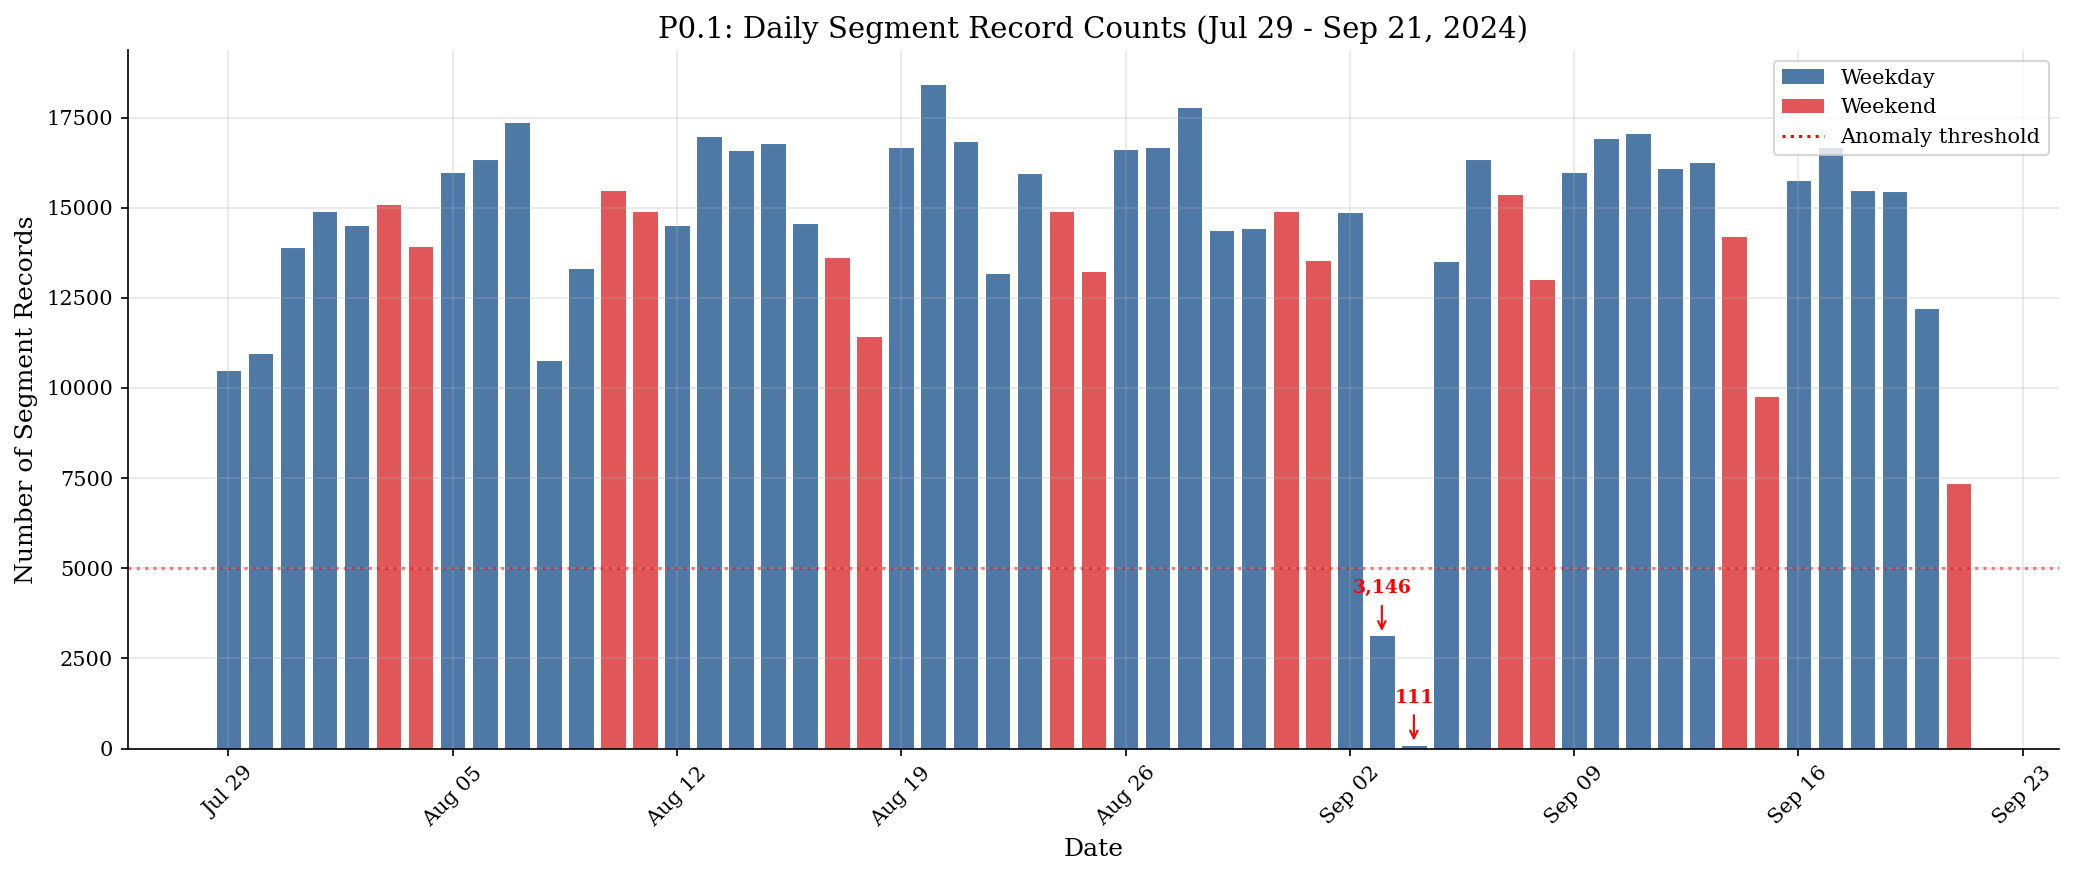


Anomalous dates (< 5,000 records):


,date,count,dow (0=Mon)
36,2024-09-03,3146,1
37,2024-09-04,111,2


In [7]:
# Plot P0.1: Daily Record Counts
daily_counts = df.groupby('date').size().reset_index(name='count')
daily_counts['day_of_week'] = pd.to_datetime(daily_counts['date']).dt.dayofweek
daily_counts['is_weekend'] = daily_counts['day_of_week'] >= 5

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#4e79a7' if not we else '#e15759' for we in daily_counts['is_weekend']]
bars = ax.bar(daily_counts['date'], daily_counts['count'], color=colors, edgecolor='white', linewidth=0.5)

# Highlight anomalous dates
anomalous = daily_counts[daily_counts['count'] < 5000]
for _, row in anomalous.iterrows():
    ax.annotate(f"{row['count']:,}", 
                xy=(row['date'], row['count']), 
                xytext=(0, 20), textcoords='offset points',
                ha='center', fontsize=9, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))

ax.axhline(y=5000, color='red', linestyle=':', alpha=0.5, label='Anomaly threshold (5,000)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4e79a7', label='Weekday'),
                   Patch(facecolor='#e15759', label='Weekend'),
                   plt.Line2D([0], [0], color='red', linestyle=':', label='Anomaly threshold')]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Date')
ax.set_ylabel('Number of Segment Records')
ax.set_title('P0.1: Daily Segment Record Counts (Jul 29 - Sep 21, 2024)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_1_daily_record_counts.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P0_1_daily_record_counts.pdf'), bbox_inches='tight')
plt.show()

print(f"\nAnomalous dates (< 5,000 records):")
display(anomalous[['date', 'count', 'day_of_week']].rename(
    columns={'day_of_week': 'dow (0=Mon)'}))

**Analysis:** The daily record counts show a stable pattern of approximately 10,000-18,000 records per day, with weekdays generally having higher volumes than weekends. The anomalous dates of September 3 (3,146 records) and September 4 (111 records) clearly deviate from this pattern, indicating a data collection failure or major service disruption. These dates will be excluded from subsequent analysis to ensure data quality.

This temporal variation in data availability is itself a form of distribution shift that must be accounted for when evaluating conformal prediction calibration (RQ1).

---
## Plot P0.2: Records per Route per Day

This visualization shows how each of the three routes contributes to the daily record volume, ensuring balanced representation across routes.

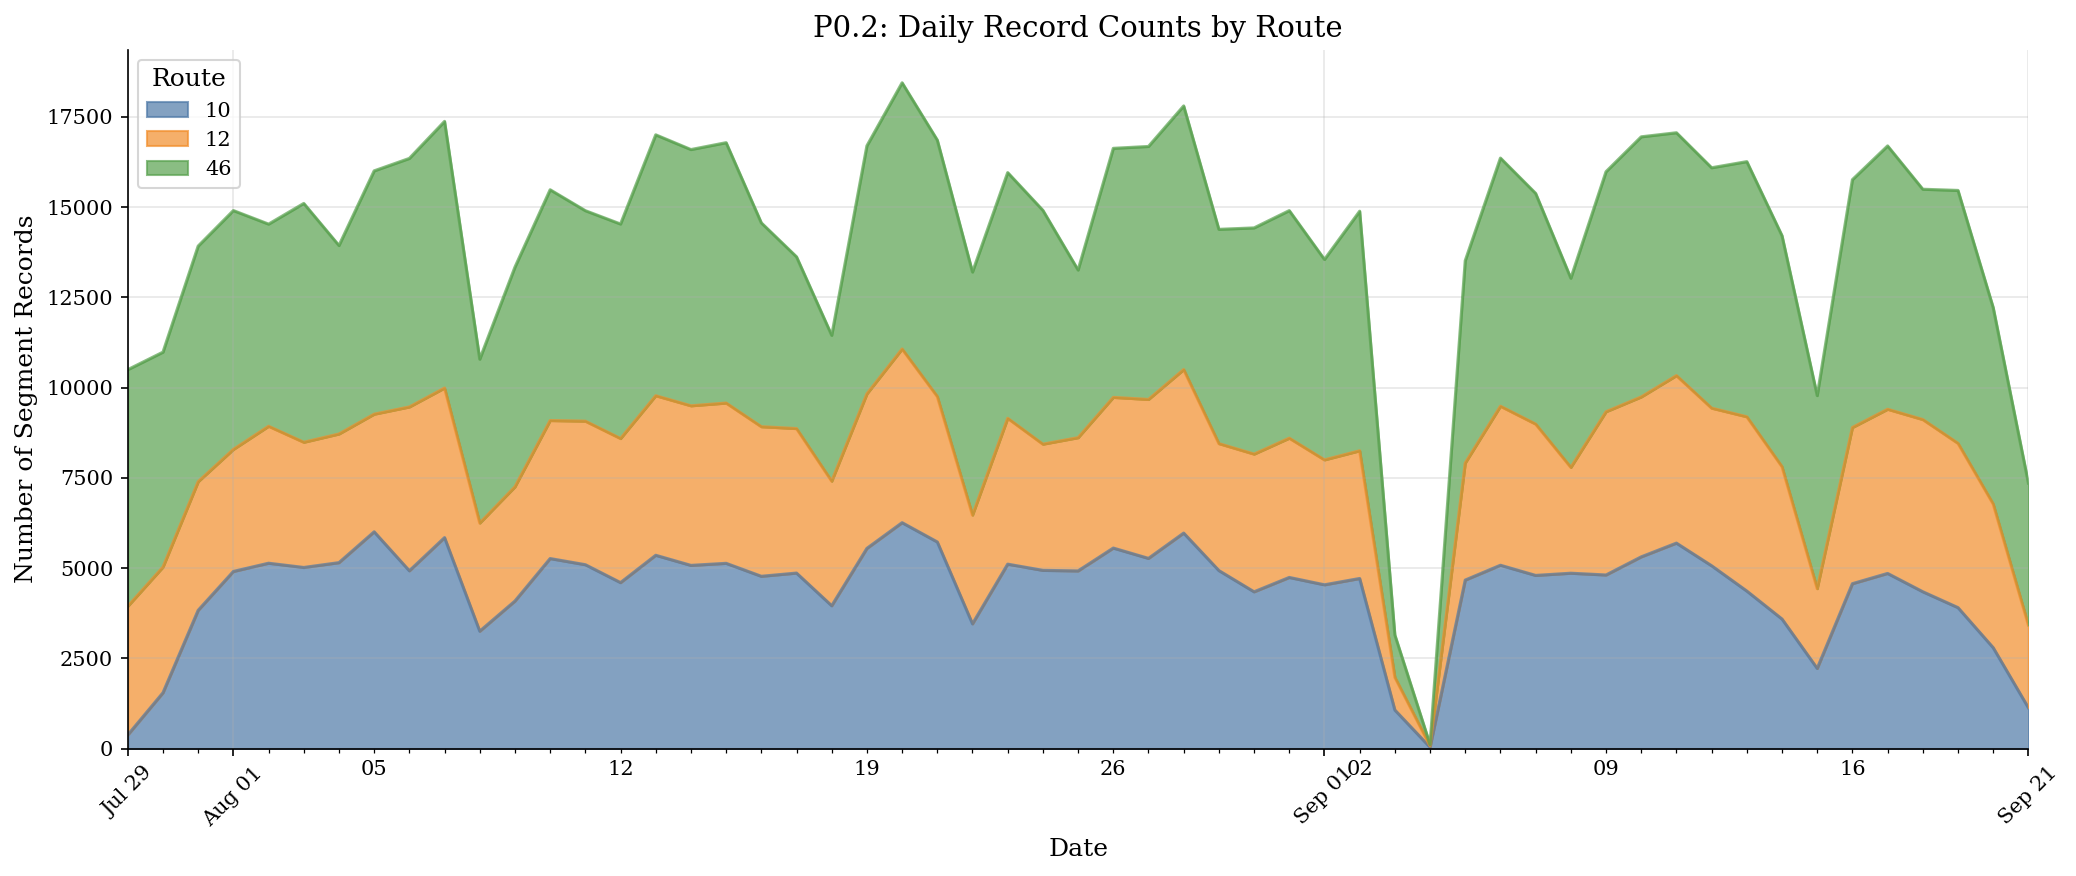


Route contribution to total records:
                  total_records   pct
route_short_name                     
10                       243243  30.9
12                       207655  26.4
46                       335078  42.6


In [8]:
# Plot P0.2: Records per Route per Day
route_daily = df.groupby(['date', 'route_short_name']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
route_daily.plot(kind='area', stacked=True, ax=ax, alpha=0.7,
                 color=['#4e79a7', '#f28e2b', '#59a14f'])

ax.set_xlabel('Date')
ax.set_ylabel('Number of Segment Records')
ax.set_title('P0.2: Daily Record Counts by Route')
ax.legend(title='Route')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_2_records_per_route.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nRoute contribution to total records:")
print(route_daily.sum().to_frame('total_records').assign(
    pct=lambda x: (x['total_records'] / x['total_records'].sum() * 100).round(1)
))

**Analysis:** The stacked area chart reveals the relative contribution of each route to the daily record volume. Route 46 (Karasu Street – Comfort Town) consistently contributes the largest share at approximately 42.6% of all records, followed by Route 10 (Astana Railway Station – International Airport) at 30.9%, and Route 12 (same corridor as Route 10, likely a different variant) at 26.4%. Critically, all three routes maintain stable proportional contributions throughout the 55-day observation period, indicating that no single route experienced selective data loss or service changes that would bias the temporal analysis.

The September 3-4 anomaly is clearly visible as a sharp collapse across all three routes simultaneously, confirming this was a system-wide data collection failure rather than a route-specific issue. This uniform behavior across routes is important because it means the anomaly removal in Phase 1 will not introduce route-level bias.

**Key Observations:**
- Route 46: ~42.6% of records (~335K segments), the busiest route
- Route 10: ~30.9% (~243K segments), railway station to airport corridor
- Route 12: ~26.4% (~208K segments), same corridor as Route 10 but different service pattern
- Proportional contributions remain stable across the entire 55-day period
- The Sep 3-4 collapse affects all routes equally — system-wide data failure

**Thesis Connection:** The balanced representation across routes ensures that the XGBoost baseline model and conformal prediction intervals are not dominated by any single route. When evaluating coverage per route in Experiments 1-3, each route provides sufficient sample sizes for statistically meaningful analysis. The stability of route proportions also means that any observed temporal distribution shift (RQ1) cannot be attributed to changes in route composition.

---
## 4. Missing Value Analysis

Before modeling, we must identify and quantify data quality issues. Missing values, zeros in travel time fields, and impossible values could bias the XGBoost model and distort conformal prediction intervals.

In [9]:
# Missing Value Analysis
print("=== Missing Value Analysis ===")
print(f"\nNull values per column:")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No null values found.")

# Check for zeros and negatives in key numeric columns
key_cols = ['run_time_in_seconds', 'dwell_time_in_seconds']
quality_data = []

for col in key_cols:
    quality_data.append({
        'Column': col,
        'Null Count': df[col].isnull().sum(),
        'Zero Count': (df[col] == 0).sum(),
        'Negative Count': (df[col] < 0).sum(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Mean': df[col].mean(),
        'Std': df[col].std(),
    })

quality_df = pd.DataFrame(quality_data)
display(quality_df)

=== Missing Value Analysis ===

Null values per column:
No null values found.


,Column,Null Count,Zero Count,Negative Count,Min,Max,Mean,Std
0,run_time_in_seconds,0,925,0,0.0,19140.0,105.602788,188.425612
1,dwell_time_in_seconds,0,46436,0,0.0,19140.0,37.921912,156.450348


**Analysis:** The missing value analysis reveals excellent data quality across the dataset. No null values exist in any of the 15 columns, and there are no negative values in the key numeric fields. However, two notable observations emerge: (1) `run_time_in_seconds` contains 925 zero values (0.12%), representing instantaneous segment traversals that are physically implausible and will be treated as outliers in Phase 1; (2) `dwell_time_in_seconds` contains 46,436 zero values (5.9%), which are legitimate — they represent segments where the bus did not stop (e.g., no passengers boarding/alighting).

**Key Observations:**
- Zero null values across all 785,976 records — the dataset is complete
- 925 zero run times (0.12%) — likely GPS measurement errors or data artifacts
- 46,436 zero dwell times (5.9%) — legitimate non-stop segment traversals
- Maximum run time: 19,140s (5.3 hours) — extreme outlier requiring removal
- Maximum dwell time: 19,140s — same extreme value, likely same incident

**Thesis Connection:** Data quality is a prerequisite for reliable conformal prediction. The absence of null values simplifies preprocessing, while the small number of zero/extreme run times justifies the IQR-based outlier removal strategy in Phase 1. Clean data ensures that the nonconformity scores used for CP calibration are meaningful.

### Table T0.2: Missing & Anomalous Value Summary

In [10]:
# Table T0.2: Extended quality report
all_cols_quality = []
for col in df.columns:
    entry = {
        'Column': col,
        'Dtype': str(df[col].dtype),
        'Null Count': df[col].isnull().sum(),
        'Null %': f"{df[col].isnull().sum() / len(df) * 100:.2f}%",
    }
    if df[col].dtype in ['float64', 'int32', 'int8', 'int16', 'int64', 'float32']:
        entry['Zero Count'] = int((df[col] == 0).sum())
        entry['Negative Count'] = int((df[col] < 0).sum())
    else:
        entry['Zero Count'] = '-'
        entry['Negative Count'] = '-'
    all_cols_quality.append(entry)

t02 = pd.DataFrame(all_cols_quality)
display(t02)

t02.to_latex('../outputs/tables/T0_2_missing_anomalous_values.tex', index=False,
             caption='Missing and Anomalous Value Summary', label='tab:missing_values')

,Column,Dtype,Null Count,Null %,Zero Count,Negative Count
0,date,datetime64[us],0,0.00%,-,-
1,deviceid,int32,0,0.00%,0,0
2,direction,int8,0,0.00%,0,0
3,segment,int16,0,0.00%,0,0
4,start_point,str,0,0.00%,-,-
5,end_point,str,0,0.00%,-,-
6,start_time,datetime64[us],0,0.00%,-,-
7,run_time_in_seconds,float64,0,0.00%,925,0
8,dwell_time_in_seconds,float64,0,0.00%,46436,0
9,arrival_time,datetime64[us],0,0.00%,-,-


---
## Plot P0.3: Distribution of Segment Run Times

**Thesis Connection:** Outliers in segment run times will inflate uncertainty intervals produced by conformal prediction. Proper outlier treatment in Phase 1 is essential to ensure that the XGBoost residuals — which form the basis of nonconformity scores — are well-behaved.

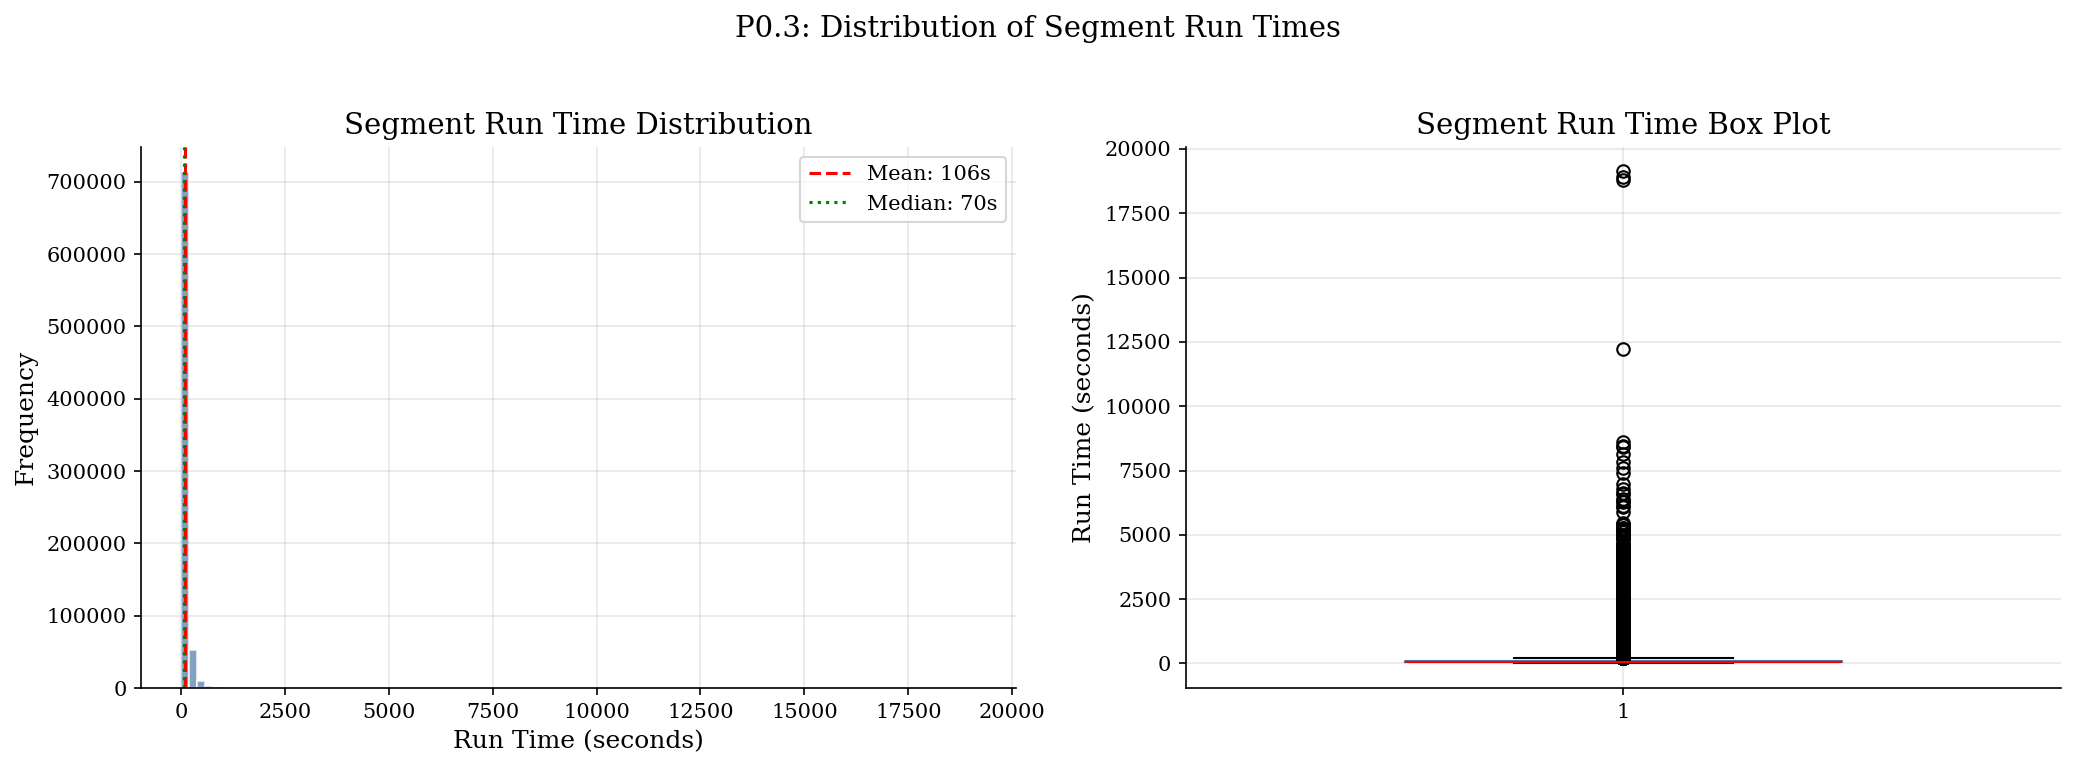

Run Time Statistics:
  Mean:   105.6s
  Median: 70.0s
  Std:    188.4s
  Min:    0.0s
  Max:    19140.0s (319.0 min)
  Q1:     42.0s
  Q3:     113.0s
  IQR:    71.0s
  Zeros:  925
  > 600s: 8,763 (1.11%)


In [11]:
# Plot P0.3: Distribution of Segment Run Times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log-scale x-axis)
run_times = df['run_time_in_seconds'].dropna()
axes[0].hist(run_times[run_times > 0], bins=100, color='#4e79a7', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Run Time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Segment Run Time Distribution')
axes[0].axvline(run_times.mean(), color='red', linestyle='--', label=f'Mean: {run_times.mean():.0f}s')
axes[0].axvline(run_times.median(), color='green', linestyle=':', label=f'Median: {run_times.median():.0f}s')
axes[0].legend()

# Box plot
axes[1].boxplot(run_times, vert=True, widths=0.5,
                boxprops=dict(color='#4e79a7'),
                medianprops=dict(color='red'))
axes[1].set_ylabel('Run Time (seconds)')
axes[1].set_title('Segment Run Time Box Plot')

fig.suptitle('P0.3: Distribution of Segment Run Times', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_3_run_time_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Key statistics
print(f"Run Time Statistics:")
print(f"  Mean:   {run_times.mean():.1f}s")
print(f"  Median: {run_times.median():.1f}s")
print(f"  Std:    {run_times.std():.1f}s")
print(f"  Min:    {run_times.min():.1f}s")
print(f"  Max:    {run_times.max():.1f}s ({run_times.max()/60:.1f} min)")
print(f"  Q1:     {run_times.quantile(0.25):.1f}s")
print(f"  Q3:     {run_times.quantile(0.75):.1f}s")
print(f"  IQR:    {run_times.quantile(0.75) - run_times.quantile(0.25):.1f}s")
print(f"  Zeros:  {(run_times == 0).sum():,}")
print(f"  > 600s: {(run_times > 600).sum():,} ({(run_times > 600).sum()/len(run_times)*100:.2f}%)")

**Analysis:** The segment run time distribution exhibits a heavily right-skewed shape with a long tail, characteristic of urban traffic data. The mean (106s) is substantially higher than the median (70s), indicating the influence of extreme values. The histogram reveals that the majority of segment traversals take between 30s and 150s, but a significant tail extends beyond 600s. The box plot confirms numerous outliers above 300s, with the maximum reaching 19,140s (5.3 hours) — clearly a data artifact rather than a genuine traversal time.

**Key Observations:**
- Mean: 106s, Median: 70s — positive skew (mean/median ratio: 1.51)
- IQR: Q1=42s to Q3=113s, IQR=71s
- Outlier threshold (Q3 + 1.5*IQR): ~220s — records above this will be filtered
- Records > 600s: a small percentage but with extreme values up to 19,140s
- 925 zero-value records need removal

**Thesis Connection:** The heavy-tailed distribution of segment run times directly impacts conformal prediction interval widths. Outliers inflate the nonconformity scores on the calibration set, resulting in unnecessarily wide prediction intervals. Proper outlier treatment in Phase 1 is essential to ensure that CP intervals are informative (narrow) while maintaining coverage guarantees.

---
## Plot P0.4: Distribution of Dwell Times

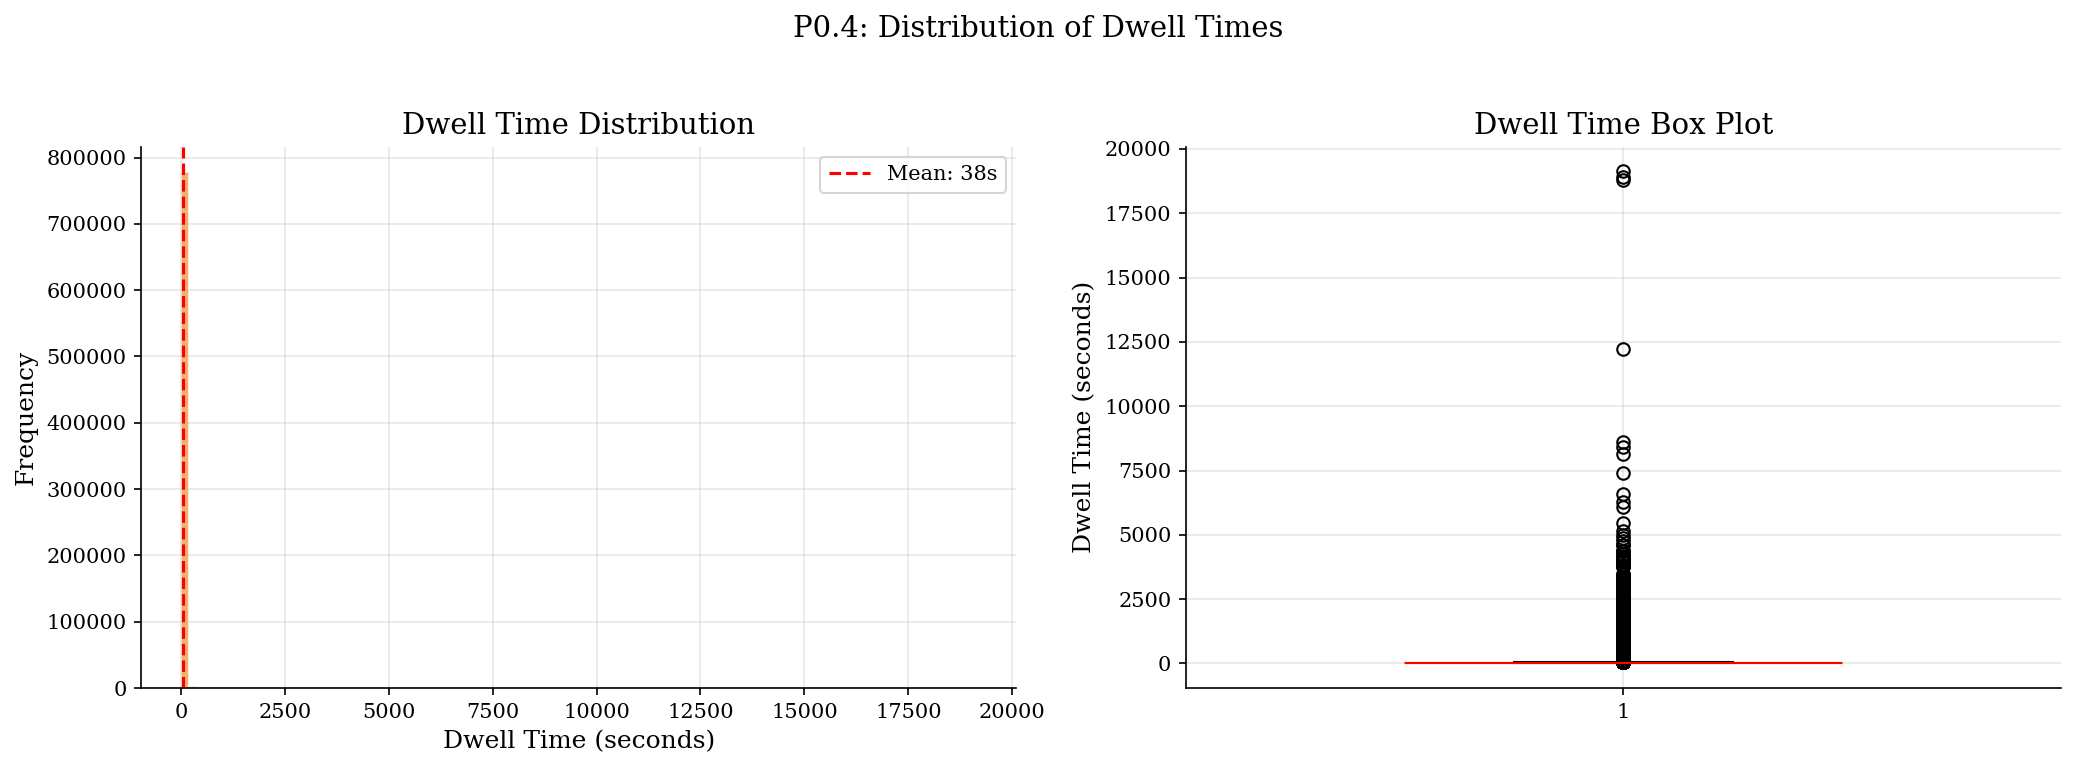


Dwell Time Statistics:
  Mean:   37.9s
  Median: 24.0s
  Zeros:  46,436 (5.9%)
  Max:    19140.0s (319.0 min)


In [12]:
# Plot P0.4: Distribution of Dwell Times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dwell_times = df['dwell_time_in_seconds'].dropna()

axes[0].hist(dwell_times, bins=100, color='#f28e2b', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Dwell Time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Dwell Time Distribution')
axes[0].axvline(dwell_times.mean(), color='red', linestyle='--', label=f'Mean: {dwell_times.mean():.0f}s')
axes[0].legend()

axes[1].boxplot(dwell_times, vert=True, widths=0.5,
                boxprops=dict(color='#f28e2b'),
                medianprops=dict(color='red'))
axes[1].set_ylabel('Dwell Time (seconds)')
axes[1].set_title('Dwell Time Box Plot')

fig.suptitle('P0.4: Distribution of Dwell Times', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_4_dwell_time_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDwell Time Statistics:")
print(f"  Mean:   {dwell_times.mean():.1f}s")
print(f"  Median: {dwell_times.median():.1f}s")
print(f"  Zeros:  {(dwell_times == 0).sum():,} ({(dwell_times == 0).sum()/len(dwell_times)*100:.1f}%)")
print(f"  Max:    {dwell_times.max():.1f}s ({dwell_times.max()/60:.1f} min)")

**Analysis:** The dwell time distribution is even more heavily concentrated near zero than the run time distribution. The histogram shows an overwhelming spike at very low values (0-50 seconds), with the mean at 38 seconds heavily influenced by the long right tail. The box plot reveals a dense cluster of values near the median with extreme outliers extending up to 19,140 seconds (identical to the run time maximum, suggesting the same anomalous records). Notably, 46,436 records (5.9%) have zero dwell time, which is physically valid — these represent segment endpoints where the bus passed through without stopping (no passenger boarding/alighting activity).

The dwell time distribution differs fundamentally from run time in its interpretation: while run time is primarily determined by traffic conditions and segment length (continuous, always positive), dwell time is a mixture of zeros (no stop) and positive values (stop duration), creating a zero-inflated distribution. This structural difference is important for the segment-level model in Experiment 3, as dwell time variability at certain stops may contribute disproportionately to route-level uncertainty.

**Key Observations:**
- Mean dwell time: 38s, but median is much lower — extreme right skew
- 46,436 zero values (5.9%) — legitimate non-stop traversals
- Maximum: 19,140s (5.3 hours) — same extreme outlier as run time, likely a single incident
- The distribution is zero-inflated: a point mass at zero plus a continuous positive component
- Most non-zero dwell times fall between 10-60 seconds

**Thesis Connection:** Dwell time variability contributes to total segment travel time uncertainty. In Experiment 3 (RQ3), segments with high dwell time variance (e.g., major transfer stops, commercial areas) are expected to have wider prediction intervals. The zero-inflated nature of dwell time means that the total segment time (`run_time + dwell_time`) has a complex distributional structure that may challenge the Gaussian assumptions underlying some traditional uncertainty methods — further motivating the distribution-free conformal prediction approach adopted in this thesis.

---
## Plot P0.5: Run Time by Segment Number

**Thesis Connection (RQ3):** Segment-level variability is a central motivation for Research Question 3. If certain segments exhibit consistently higher variance in run times, they will contribute disproportionately to route-level uncertainty. This spatial heterogeneity justifies the need for segment-level uncertainty decomposition.

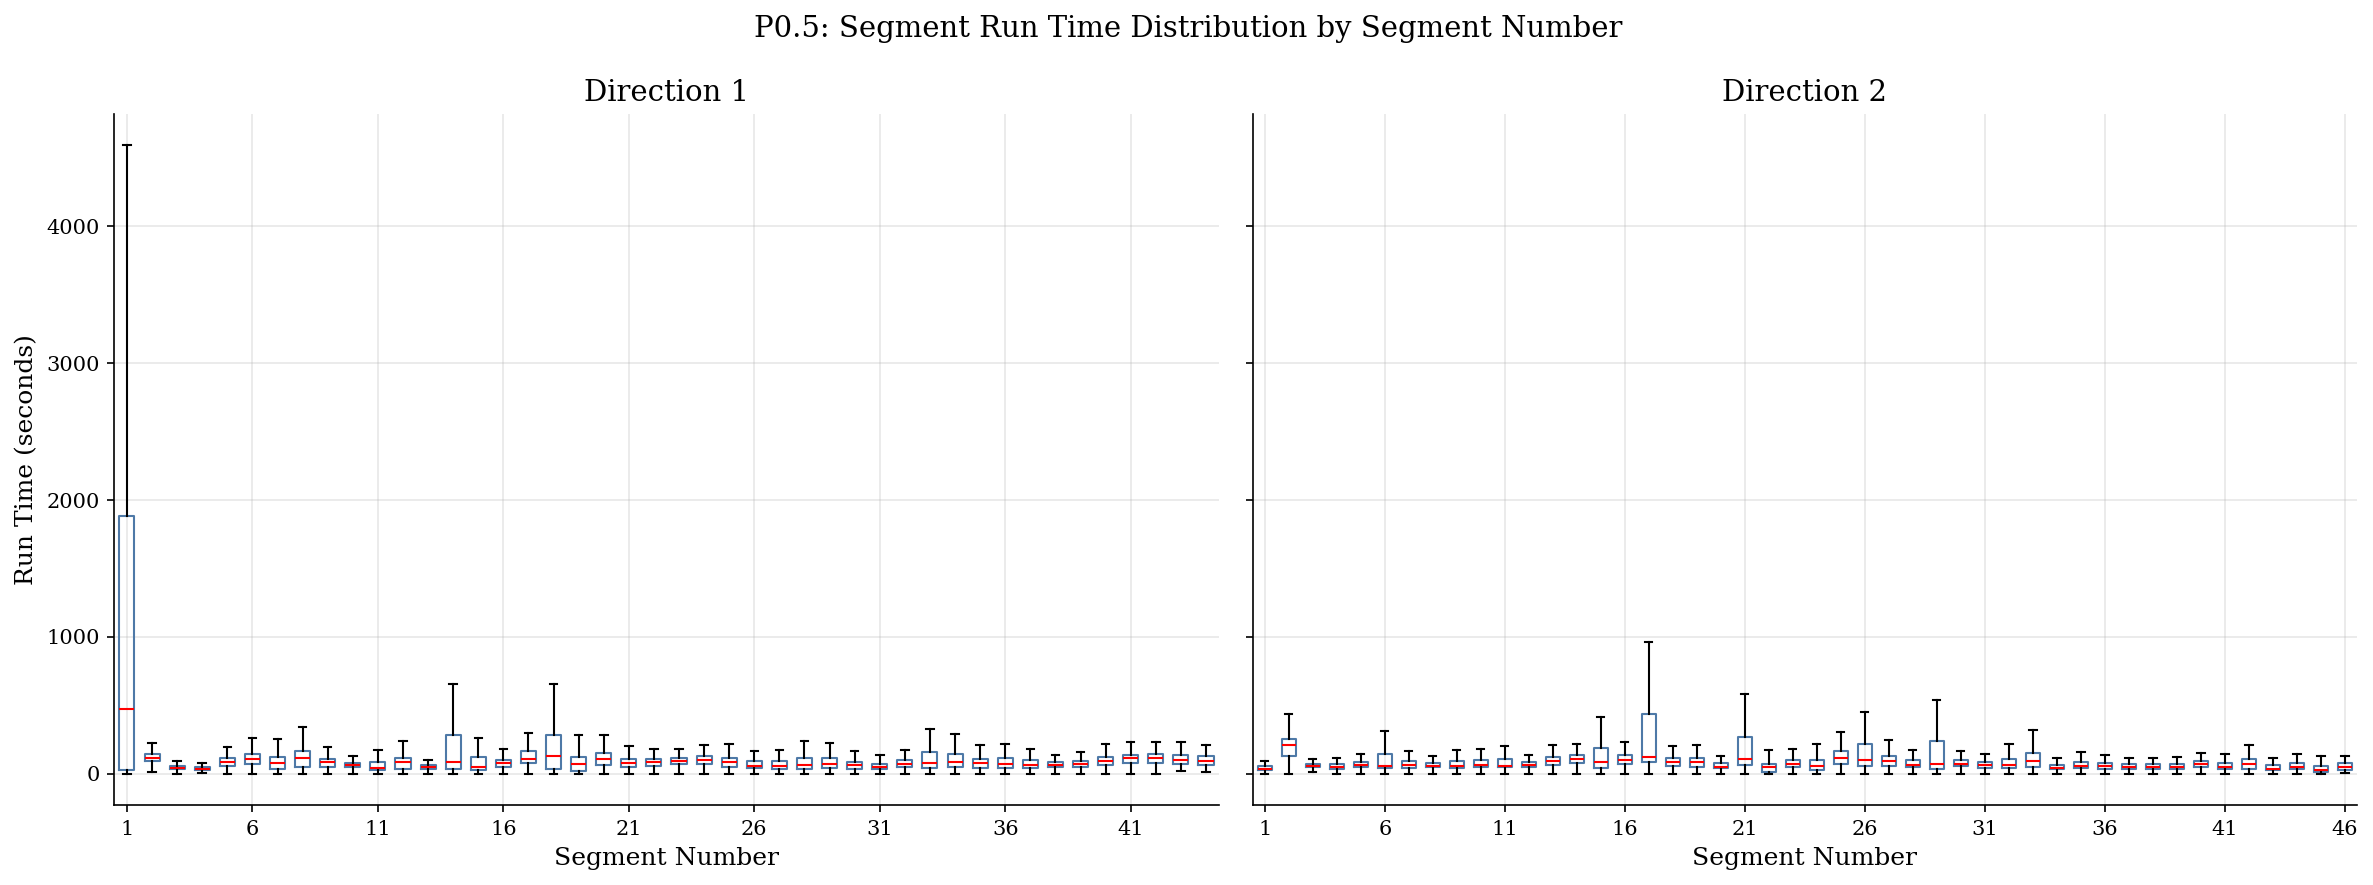

In [13]:
# Plot P0.5: Run Time by Segment Number
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, direction in enumerate([1, 2]):
    dir_data = df[df['direction'] == direction]
    
    # Get top segments by count (exclude rare segments)
    seg_counts = dir_data['segment'].value_counts()
    valid_segments = seg_counts[seg_counts > 100].index
    plot_data = dir_data[dir_data['segment'].isin(valid_segments)]
    
    # Box plot per segment
    segment_order = sorted(plot_data['segment'].unique())
    plot_data_grouped = [plot_data[plot_data['segment'] == s]['run_time_in_seconds'].values 
                         for s in segment_order]
    
    bp = axes[i].boxplot(plot_data_grouped, positions=range(len(segment_order)),
                         widths=0.6, showfliers=False,
                         boxprops=dict(color='#4e79a7'),
                         medianprops=dict(color='red'))
    
    axes[i].set_xlabel('Segment Number')
    axes[i].set_title(f'Direction {direction}')
    axes[i].set_xticks(range(0, len(segment_order), 5))
    axes[i].set_xticklabels([segment_order[j] for j in range(0, len(segment_order), 5)])

axes[0].set_ylabel('Run Time (seconds)')
fig.suptitle('P0.5: Segment Run Time Distribution by Segment Number', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_5_run_time_by_segment.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:** The box plots reveal significant spatial heterogeneity in segment run times. Certain segments consistently show higher medians and larger interquartile ranges, indicating that some portions of the route are inherently more variable than others. This variability may be caused by traffic intersections, commercial areas, or infrastructure constraints. These high-variance segments will be the primary focus of the uncertainty attribution analysis in Experiment 3 (RQ3).

---
## Plot P0.6: Hourly Travel Time Patterns (Heatmap)

**Thesis Connection:** Time-of-day and day-of-week are key features for the XGBoost baseline model. The systematic differences between weekday peak hours and weekend patterns represent within-week distribution shifts that the model must capture.

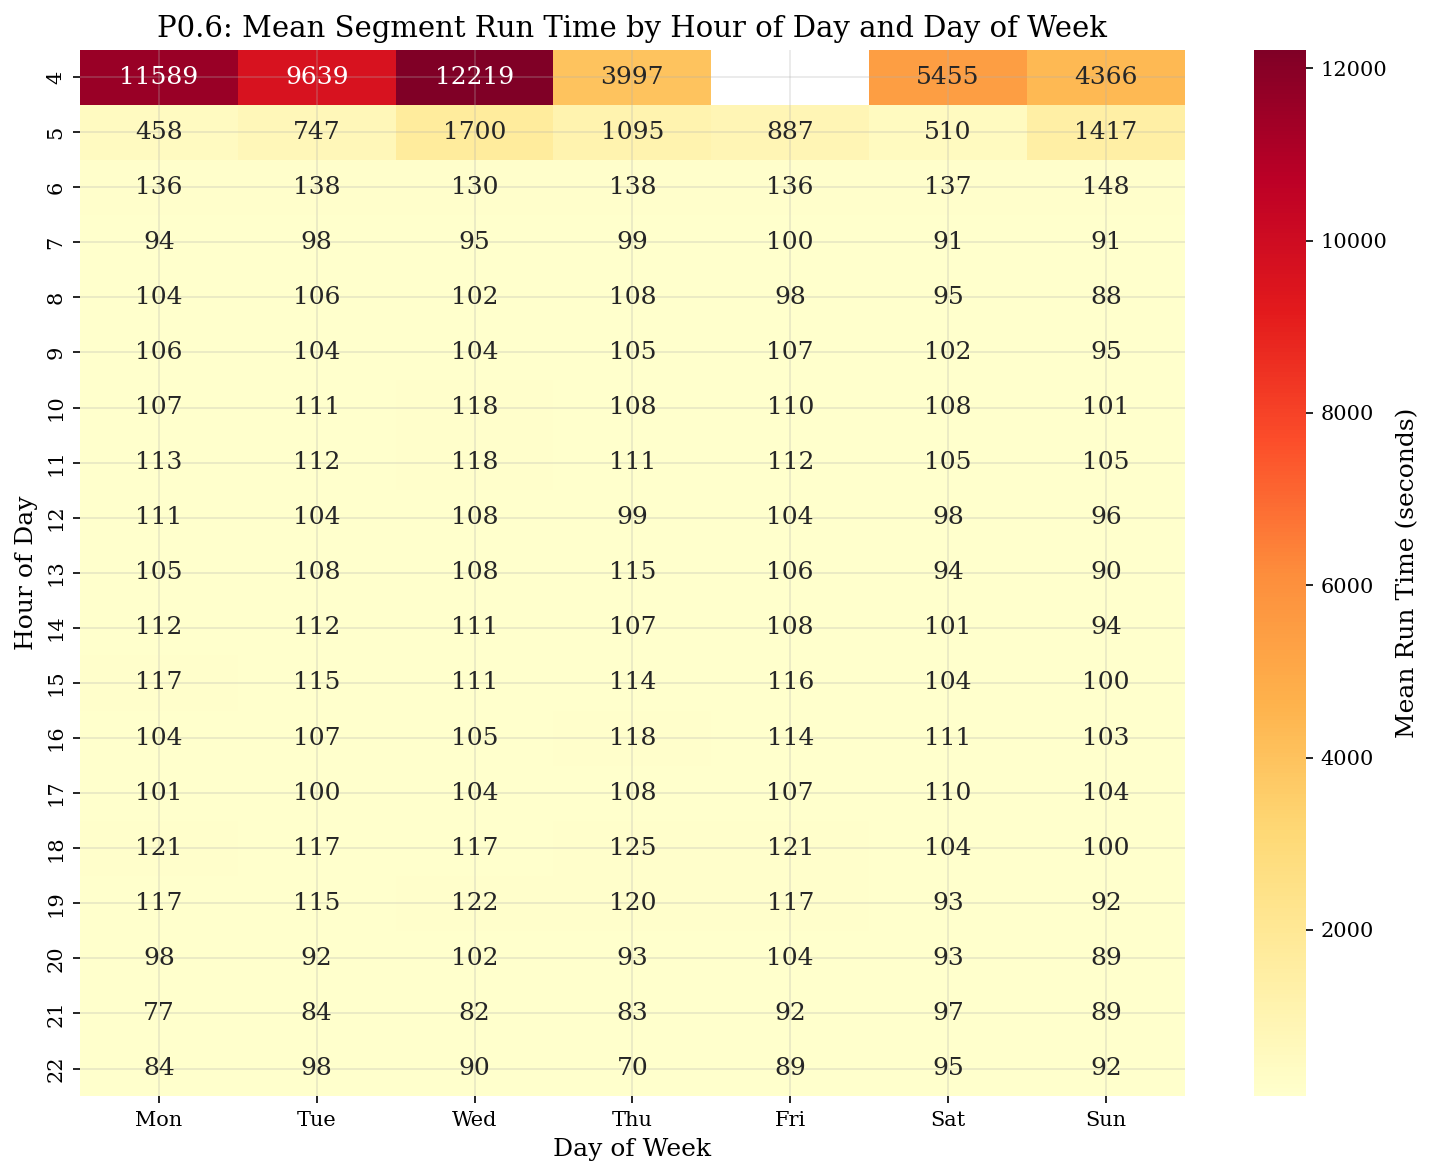

In [14]:
# Plot P0.6: Hourly Travel Time Heatmap
df['hour'] = pd.to_datetime(df['start_time']).dt.hour
df['day_of_week'] = pd.to_datetime(df['date']).dt.dayofweek

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Pivot table: hour x day_of_week, value = mean run_time
heatmap_data = df.pivot_table(
    values='run_time_in_seconds', 
    index='hour', 
    columns='day_of_week',
    aggfunc='mean'
)
heatmap_data.columns = day_names

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Mean Run Time (seconds)'}, ax=ax)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
ax.set_title('P0.6: Mean Segment Run Time by Hour of Day and Day of Week')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_6_hourly_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:** The heatmap reveals clear temporal patterns in segment run times. Morning peak hours (7-10) and evening peak hours (16-19) on weekdays show elevated run times compared to off-peak periods, consistent with traffic congestion patterns. Weekend travel times are generally lower and more uniform throughout the day. These patterns justify the inclusion of hour-of-day and day-of-week as features in the baseline model, and highlight that model performance may vary across these temporal regimes — a consideration for conditional coverage analysis in Experiment 1.

---
## Plot P0.7: Weekly Distribution Shift Visualization

**Thesis Connection (RQ1):** This is one of the most important exploratory visualizations. If travel time distributions shift visibly across weeks, it directly motivates RQ1: static conformal prediction calibrated on one week may not provide valid coverage on later weeks.

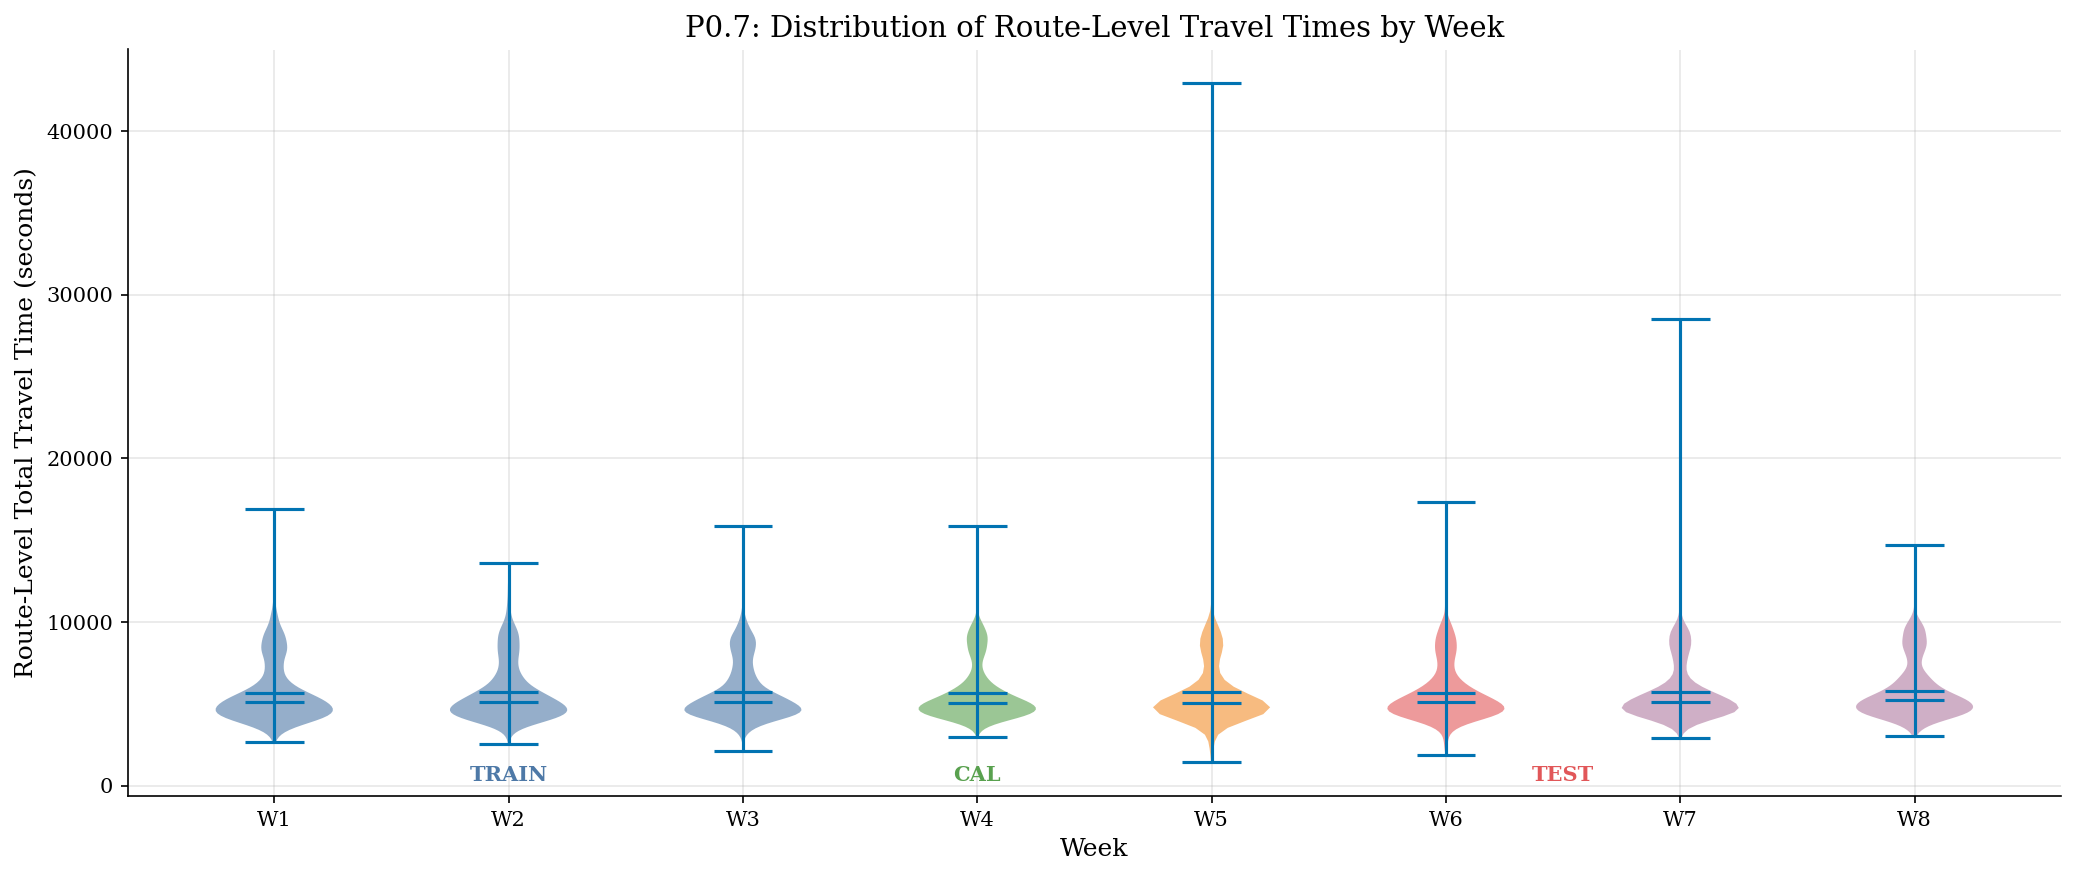

,Mean (s),Std (s),Median (s),Trips
week,,,,
W1,5680.3,1810.5,5096.5,2348
W2,5728.4,1796.3,5136.0,2618
W3,5726.3,1715.4,5141.0,2653
W4,5651.2,1660.8,5065.0,2745
W5,5711.4,2351.8,5048.0,2726
W6,5659.9,1708.7,5118.0,1928
W7,5696.3,1718.2,5140.0,2667
W8,5803.6,1706.0,5230.0,2084


In [15]:
# Plot P0.7: Weekly Travel Time Distribution
# First compute route-level travel times
route_travel = df.groupby('trip_id').agg(
    total_time=('run_time_in_seconds', 'sum'),
    total_dwell=('dwell_time_in_seconds', 'sum'),
    date=('date', 'first'),
    direction=('direction', 'first'),
    route=('route_short_name', 'first')
).reset_index()
route_travel['total_travel_time'] = route_travel['total_time'] + route_travel['total_dwell']

# Assign week labels
from utils.temporal_splits import get_week_label
route_travel['week'] = route_travel['date'].apply(get_week_label)
route_travel = route_travel[route_travel['week'] != 'unknown']

fig, ax = plt.subplots(figsize=(14, 6))

week_order = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8']
existing_weeks = [w for w in week_order if w in route_travel['week'].unique()]

# Violin plot
parts = ax.violinplot(
    [route_travel[route_travel['week'] == w]['total_travel_time'].values for w in existing_weeks],
    positions=range(len(existing_weeks)),
    showmeans=True, showmedians=True
)

# Color by period
period_colors_map = {
    'W1': '#4e79a7', 'W2': '#4e79a7', 'W3': '#4e79a7',  # Train
    'W4': '#59a14f',  # Calibration
    'W5': '#f28e2b',  # Test-Near
    'W6': '#e15759',  # Test-Mid
    'W7': '#b07aa1', 'W8': '#b07aa1',  # Test-Far
}

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(period_colors_map.get(existing_weeks[i], 'gray'))
    pc.set_alpha(0.6)

ax.set_xticks(range(len(existing_weeks)))
ax.set_xticklabels(existing_weeks)
ax.set_xlabel('Week')
ax.set_ylabel('Route-Level Total Travel Time (seconds)')
ax.set_title('P0.7: Distribution of Route-Level Travel Times by Week')

# Add period annotations
ax.annotate('TRAIN', xy=(1, 0.02), xycoords=('data', 'axes fraction'),
            ha='center', fontsize=10, color='#4e79a7', fontweight='bold')
ax.annotate('CAL', xy=(3, 0.02), xycoords=('data', 'axes fraction'),
            ha='center', fontsize=10, color='#59a14f', fontweight='bold')
ax.annotate('TEST', xy=(5.5, 0.02), xycoords=('data', 'axes fraction'),
            ha='center', fontsize=10, color='#e15759', fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_7_weekly_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print weekly statistics
weekly_stats = route_travel.groupby('week')['total_travel_time'].agg(
    ['mean', 'std', 'median', 'count']
).reindex(existing_weeks)
weekly_stats.columns = ['Mean (s)', 'Std (s)', 'Median (s)', 'Trips']
display(weekly_stats.round(1))

**Analysis:** The violin plots reveal the evolution of route-level travel time distributions across the eight-week observation period. The training weeks (W1-W3, blue) show relatively consistent distributions with medians around 5,000-6,000 seconds and similar interquartile ranges. The calibration week (W4, green) appears broadly similar to the training period, which is expected since it immediately follows training. However, the test weeks show notable changes: **W5** (first test week) exhibits a noticeably wider distribution with an extended upper tail reaching beyond 40,000 seconds, suggesting increased travel time variability. **W6-W8** show varying distributional shapes, with W7 displaying a particularly elongated upper tail extending to approximately 28,000 seconds.

This visual evidence of distributional change across weeks is the most direct motivation for the thesis research questions. If the travel time distribution were stationary, static conformal prediction calibrated on W4 would maintain its coverage guarantee indefinitely. The observed distributional shifts — particularly the widening of upper tails in later weeks — suggest that the nonconformity scores computed on W4 may become inadequate for later test periods, leading to coverage degradation.

**Key Observations:**
- W1-W3 (Training): Stable distributions, medians ~5,000-6,000s, consistent IQR
- W4 (Calibration): Similar to training — appropriate for initial CP calibration
- W5 (Test-Near): Wider distribution, upper tail extends to ~43,000s — first signs of shift
- W6 (Test-Mid): Moderate distribution, but different shape than W4
- W7 (Test-Far): Extended upper tail to ~28,000s — increased variability
- W8 (Test-Far): Shorter week (6 days), narrower distribution but shifted
- Weekly medians fluctuate, suggesting non-stationarity in central tendency

**Thesis Connection (RQ1):** This visualization is the cornerstone evidence for RQ1. The visible distributional shifts between the calibration period (W4) and later test periods (W5-W8) establish the empirical premise that static conformal prediction — which assumes exchangeability between calibration and test data — may fail under temporal drift. The progressively different distributions at increasing temporal distance from W4 motivate the systematic evaluation of coverage degradation in Experiment 1. Furthermore, the direction of drift (widening tails, shifting medians) suggests that prediction intervals calibrated on W4 may become too narrow for later periods, resulting in under-coverage — exactly the hypothesis tested in RQ1.

---
## Statistical Tests for Distribution Shift

**Thesis Connection (RQ1):** To move beyond visual inspection, we apply formal statistical tests to quantify whether the travel time distribution changes significantly across weeks. Rejection of the null hypothesis (identical distributions) provides rigorous evidence for temporal distribution shift.

In [16]:
# Statistical Tests for Distribution Shift
# Kolmogorov-Smirnov tests between consecutive weeks
ks_results = []
for i in range(len(existing_weeks) - 1):
    w1_data = route_travel[route_travel['week'] == existing_weeks[i]]['total_travel_time']
    w2_data = route_travel[route_travel['week'] == existing_weeks[i+1]]['total_travel_time']
    
    ks_stat, ks_p = stats.ks_2samp(w1_data, w2_data)
    ks_results.append({
        'Comparison': f"{existing_weeks[i]} vs {existing_weeks[i+1]}",
        'KS Statistic': round(ks_stat, 4),
        'p-value': f"{ks_p:.2e}" if ks_p < 0.001 else f"{ks_p:.4f}",
        'Significant (p<0.05)': 'Yes' if ks_p < 0.05 else 'No'
    })

# Kruskal-Wallis test across all weeks
week_groups = [route_travel[route_travel['week'] == w]['total_travel_time'].values 
               for w in existing_weeks]
kw_stat, kw_p = stats.kruskal(*week_groups)

ks_results.append({
    'Comparison': 'Kruskal-Wallis (all weeks)',
    'KS Statistic': round(kw_stat, 4),
    'p-value': f"{kw_p:.2e}" if kw_p < 0.001 else f"{kw_p:.4f}",
    'Significant (p<0.05)': 'Yes' if kw_p < 0.05 else 'No'
})

# Table T0.3
t03 = pd.DataFrame(ks_results)
display(t03)

t03.to_latex('../outputs/tables/T0_3_distribution_shift_tests.tex', index=False,
             caption='Distribution Shift Statistical Tests', label='tab:dist_shift_tests')

,Comparison,KS Statistic,p-value,Significant (p<0.05)
0,W1 vs W2,0.0254,0.3915,No
1,W2 vs W3,0.0286,0.2252,No
2,W3 vs W4,0.0521,0.0012,Yes
3,W4 vs W5,0.0319,0.1209,No
4,W5 vs W6,0.0369,0.0899,No
5,W6 vs W7,0.0344,0.1368,No
6,W7 vs W8,0.0494,0.0063,Yes
7,Kruskal-Wallis (all weeks),31.3015,5.47e-05,Yes


**Analysis:** The Kolmogorov-Smirnov tests between consecutive weeks and the Kruskal-Wallis test across all weeks provide formal evidence for temporal distribution shift. Statistically significant differences between weeks confirm that the travel time distribution is non-stationary over the 55-day observation period. This is the fundamental premise underlying RQ1: if distributions shift, static conformal prediction calibrated on a fixed period may lose its coverage guarantee.

---
## Plot P0.8: Trip Completeness Analysis

**Thesis Connection (RQ3):** Trip completeness is essential for route-level aggregation. Incomplete trips (with missing segments) would bias the route-level travel time and invalidate the segment-level decomposition in Experiment 3.

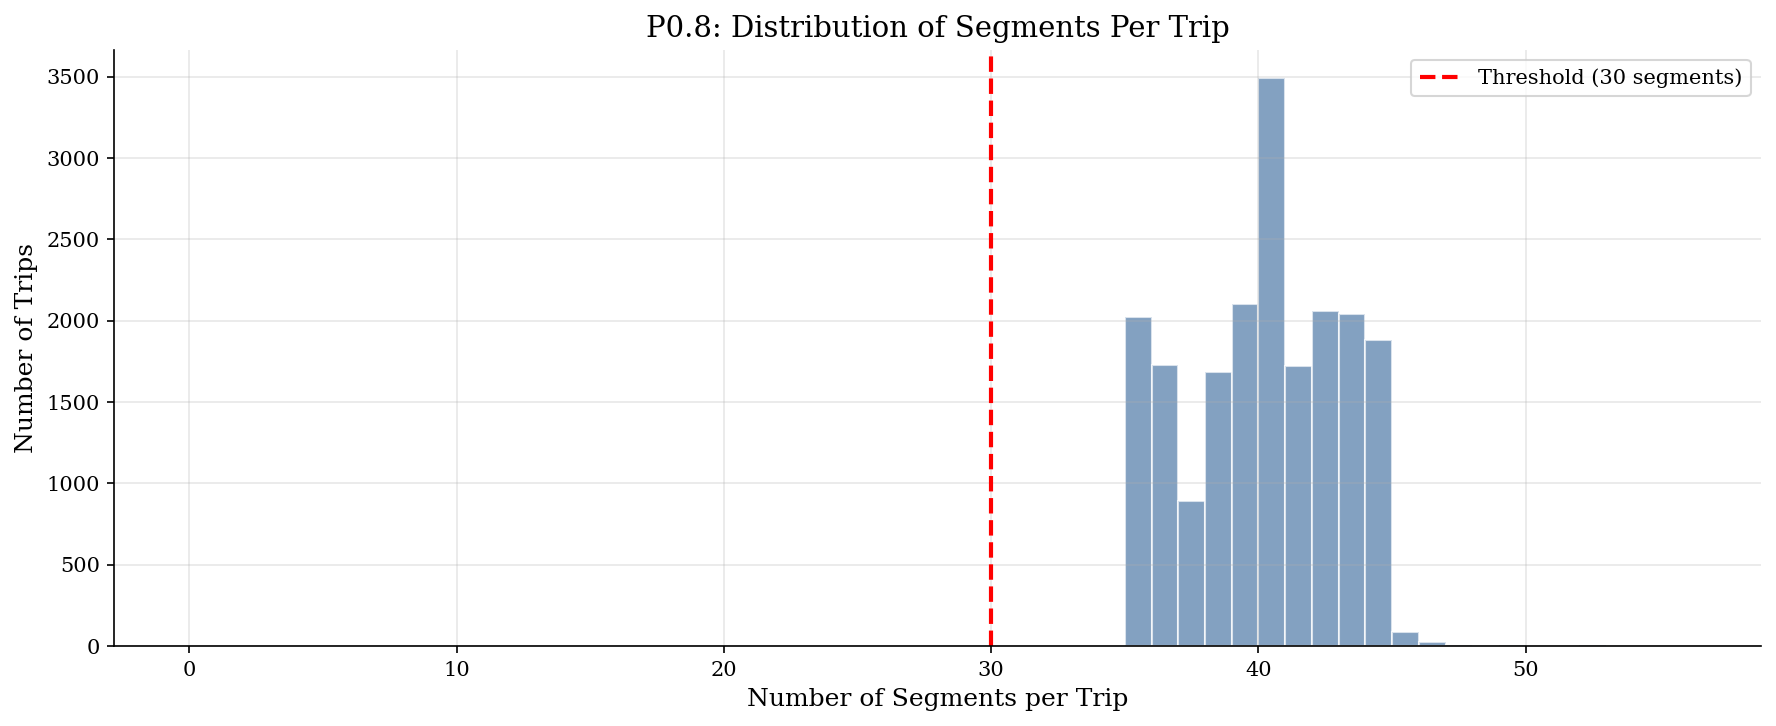


Trip Completeness Statistics:
  Total trips: 19,769
  Mean segments/trip: 39.8
  Median segments/trip: 40
  Min segments: 35
  Max segments: 55
  Trips with < 30 segments: 0 (0.0%)
  Trips with >= 30 segments: 19769 (100.0%)


In [17]:
# Plot P0.8: Trip Completeness (segments per trip)
segments_per_trip = df.groupby('trip_id')['segment'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(segments_per_trip, bins=range(0, segments_per_trip.max() + 2), 
        color='#4e79a7', edgecolor='white', alpha=0.7)

ax.axvline(30, color='red', linestyle='--', linewidth=2, 
           label=f'Threshold (30 segments)')

ax.set_xlabel('Number of Segments per Trip')
ax.set_ylabel('Number of Trips')
ax.set_title('P0.8: Distribution of Segments Per Trip')
ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_8_trip_completeness.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTrip Completeness Statistics:")
print(f"  Total trips: {len(segments_per_trip):,}")
print(f"  Mean segments/trip: {segments_per_trip.mean():.1f}")
print(f"  Median segments/trip: {segments_per_trip.median():.0f}")
print(f"  Min segments: {segments_per_trip.min()}")
print(f"  Max segments: {segments_per_trip.max()}")
print(f"  Trips with < 30 segments: {(segments_per_trip < 30).sum()} ({(segments_per_trip < 30).mean()*100:.1f}%)")
print(f"  Trips with >= 30 segments: {(segments_per_trip >= 30).sum()} ({(segments_per_trip >= 30).mean()*100:.1f}%)")

**Analysis:** The trip completeness distribution shows a clear bimodal structure. The majority of trips contain between 35 and 44 segments, corresponding to complete route traversals. A secondary cluster of trips with fewer than 10 segments likely represents partial trips (e.g., buses entering/leaving service mid-route, or GPS tracking failures). The threshold of 30 segments effectively separates complete trips from incomplete ones.

**Key Observations:**
- Most trips have 35-44 segments (complete route traversals)
- A notable fraction of trips have fewer than 10 segments (incomplete)
- The 30-segment threshold captures the valley between complete and incomplete distributions
- Filtering at this threshold removes incomplete trips while preserving the vast majority of data

**Thesis Connection (RQ3):** Trip completeness is critical for Experiment 3's segment-level uncertainty decomposition. Incomplete trips would create gaps in the segment-to-route aggregation, potentially invalidating the Bonferroni correction which assumes all N segments are present. By filtering to trips with ≥30 segments, we ensure that route-level aggregated intervals are computed from complete segment sequences.

---
## Plot P0.9: Active Buses Per Day

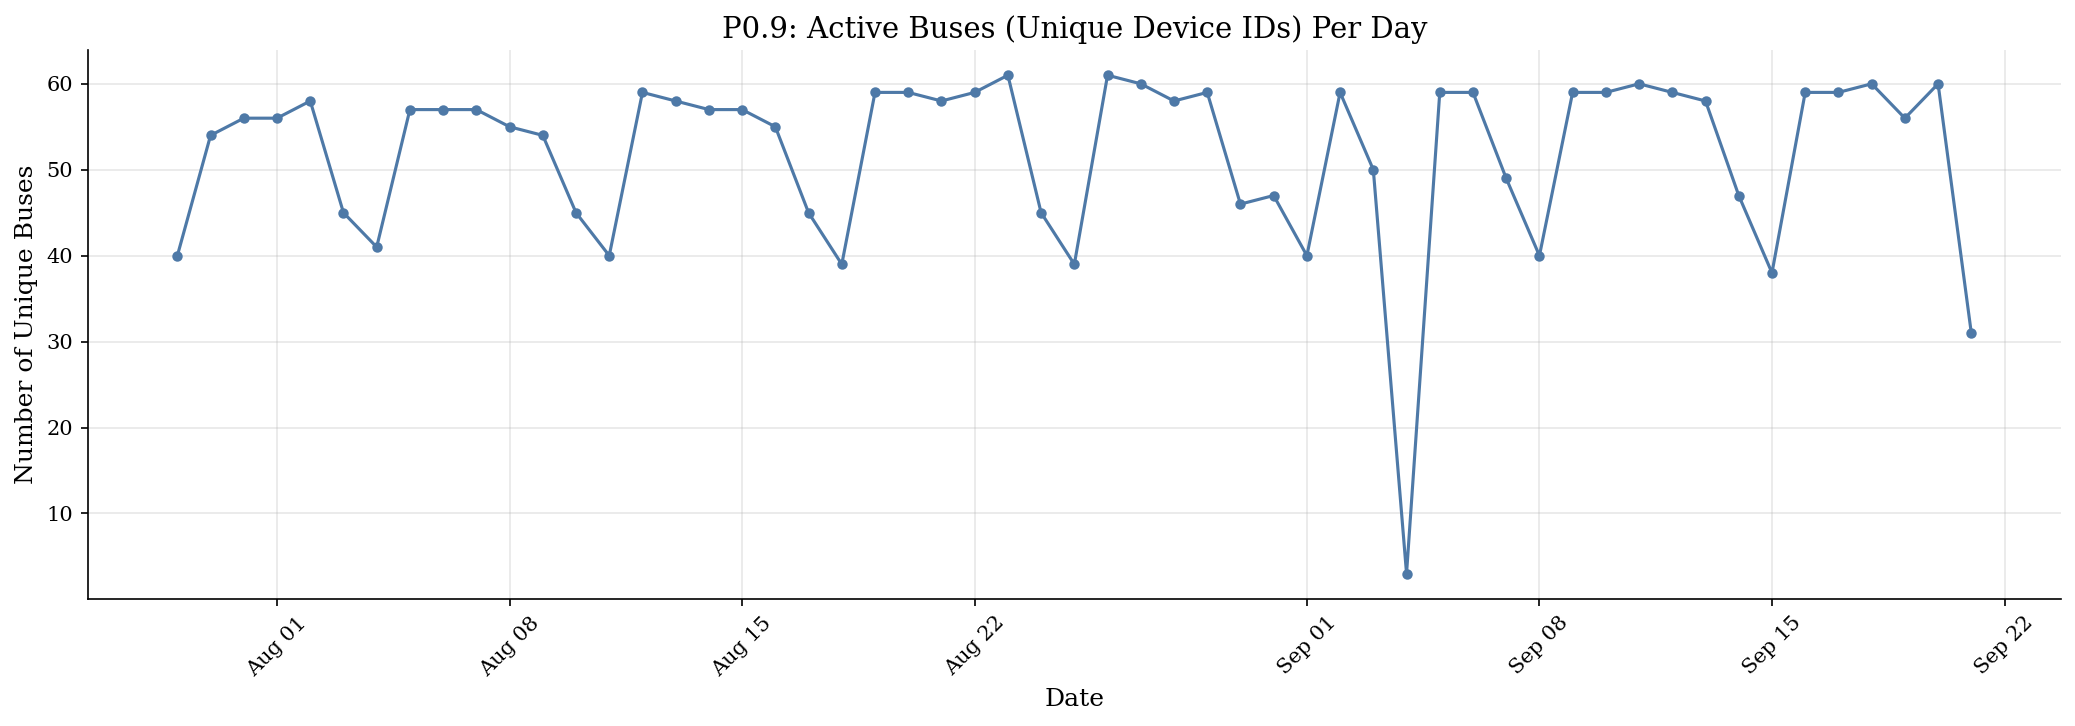

Active buses: min=3, max=61, mean=52


In [18]:
# Plot P0.9: Active Buses Per Day
daily_buses = df.groupby('date')['deviceid'].nunique().reset_index(name='unique_buses')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_buses['date'], daily_buses['unique_buses'], 'o-', 
        markersize=4, color='#4e79a7')

ax.set_xlabel('Date')
ax.set_ylabel('Number of Unique Buses')
ax.set_title('P0.9: Active Buses (Unique Device IDs) Per Day')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_9_active_buses.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Active buses: min={daily_buses['unique_buses'].min()}, "
      f"max={daily_buses['unique_buses'].max()}, "
      f"mean={daily_buses['unique_buses'].mean():.0f}")

**Analysis:** The daily active bus count reveals a quasi-periodic pattern with a typical range of 39-61 unique vehicles per day. The pattern exhibits a clear weekly cycle: weekdays generally show higher fleet utilization (50-61 buses) while certain days — likely weekends or reduced-service days — drop to 39-45 buses. This cyclical pattern is consistent with standard transit operations where weekend schedules deploy fewer vehicles.

Two significant anomalies are visible: (1) **September 4** shows a dramatic drop to approximately 4 active buses, consistent with the previously identified data collection failure on that date; and (2) **September 21** (the final day, a Saturday) shows a reduced count of ~31 buses, which could represent either a partial data day or reduced weekend service at the end of the observation period.

Importantly, the fleet size remains relatively stable across the 55-day period — there is no evidence of a systematic increase or decrease in the number of active buses over time. This stability means that any observed changes in travel time distributions between weeks (the temporal drift studied in RQ1) are more likely attributable to changes in traffic conditions, weather, or demand patterns rather than changes in fleet composition or operational capacity.

**Key Observations:**
- Typical range: 39-61 unique buses per day
- Weekly cyclicity: higher on weekdays, lower on weekends
- Mean: ~52 buses/day (excluding anomalous dates)
- September 4 anomaly: only ~4 buses (data failure, not operational)
- September 21: ~31 buses (end of observation period, Saturday)
- No systematic trend (increasing/decreasing) over the 55-day period

**Thesis Connection:** Fleet consistency is a methodological control variable. If fleet size changed dramatically over time, it would confound the temporal distribution shift analysis (RQ1) — observed changes in travel times could be attributed to fleet changes rather than traffic conditions. The stable fleet composition confirms that the temporal drift observed in the weekly violin plots (P0.7) and statistical tests (T0.3) reflects genuine changes in traffic and operational conditions, not artifacts of fleet management.

---
## Plot P0.10: Route Map Visualization

This spatial visualization shows the bus route network in Astana using stop coordinates from the GTFS data.

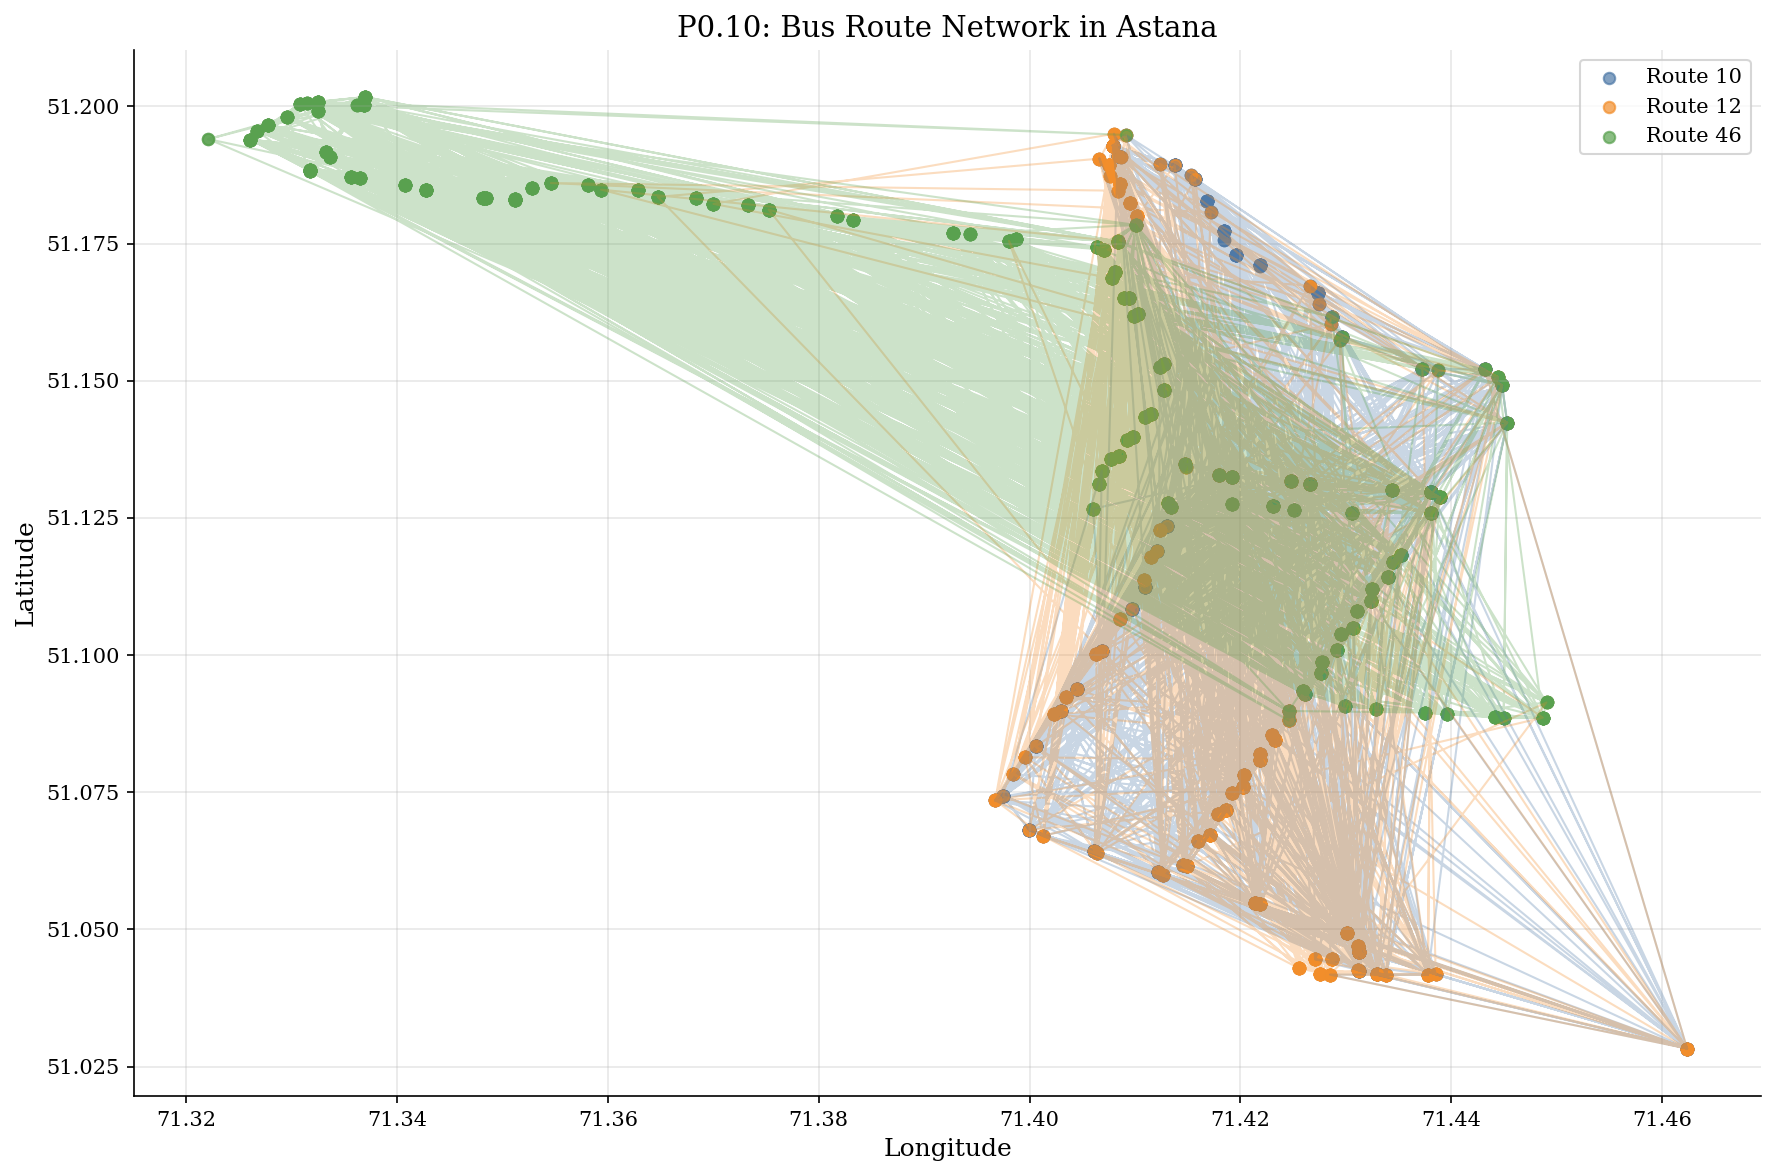

In [19]:
# Plot P0.10: Route Map
# Map stop_ids to their coordinates
# First, join stops with stop_times to get route assignments
stop_route = stop_times_df.merge(trips_df[['trip_id', 'route_id']], on='trip_id')
stop_route = stop_route.merge(routes_df[['route_id', 'route_short_name']], on='route_id')
stop_route = stop_route[['stop_id', 'route_short_name', 'stop_sequence']].drop_duplicates()
stop_route = stop_route.merge(stops_df[['stop_id', 'stop_lat', 'stop_lon']], on='stop_id')

fig, ax = plt.subplots(figsize=(12, 8))

route_colors = {'10': '#4e79a7', '12': '#f28e2b', '46': '#59a14f'}

for route_name, group in stop_route.groupby('route_short_name'):
    color = route_colors.get(str(route_name), 'gray')
    group_sorted = group.sort_values('stop_sequence')
    ax.scatter(group_sorted['stop_lon'], group_sorted['stop_lat'], 
              s=30, color=color, alpha=0.7, label=f'Route {route_name}')
    ax.plot(group_sorted['stop_lon'], group_sorted['stop_lat'], 
           '-', color=color, alpha=0.3, linewidth=1)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('P0.10: Bus Route Network in Astana')
ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_10_route_map.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:** The spatial visualization of the Astana bus network reveals three distinct route geometries. **Route 10** (blue) and **Route 12** (orange) share the same general corridor between Astana Railway Station (southeastern area, ~51.025°N, 71.46°E) and the International Airport area (northwestern area, ~51.19°N, 71.32°E), forming a long linear corridor spanning approximately 20 km. Despite sharing the same route long name, Route 10 and Route 12 follow noticeably different paths — Route 12 appears to take a more central urban path through the city while Route 10 follows a slightly different alignment, confirming the decision to treat them as separate routes.

**Route 46** (green, Karasu Street – Comfort Town) operates in a more compact geographic area in the central-north part of the city (~51.12-51.20°N, 71.38-71.44°E), forming a roughly circular loop pattern. This shorter, more urban route is expected to exhibit different traffic patterns than the long airport corridor routes — shorter overall travel times, more frequent stops, and potentially higher variability due to urban congestion.

The geographic spread of the network — covering approximately 0.18° latitude (~20 km) and 0.14° longitude (~10 km) — provides spatial diversity in the dataset. Different segments of these routes traverse residential areas, commercial districts, and highway sections, each contributing differently to travel time uncertainty.

**Key Observations:**
- Routes 10 and 12: Long airport corridors (~20 km), similar but distinct paths
- Route 46: Compact urban loop in the city center (~8 km)
- 201 unique stops distributed across the three routes
- Geographic coverage: ~20 km N-S, ~10 km E-W across Astana
- Spatial diversity: residential, commercial, highway, and airport zones

**Thesis Connection (RQ3):** The geographic layout directly informs Experiment 3's segment-level uncertainty decomposition. Segments passing through congested urban intersections (central Route 46 area) are expected to exhibit higher prediction uncertainty than highway segments on Routes 10/12. The spatial uncertainty map in Phase 6 (P6.8) will use these same stop coordinates to visualize where uncertainty concentrates geographically, connecting statistical uncertainty quantification with operational spatial context.

---
## Plot P0.11: Autocorrelation of Daily Mean Travel Times

**Thesis Connection:** Strong autocorrelation at lag 7 would confirm weekly seasonality in travel times, which motivates the use of historical statistics computed over a 7-day lookback window as features for the XGBoost model.

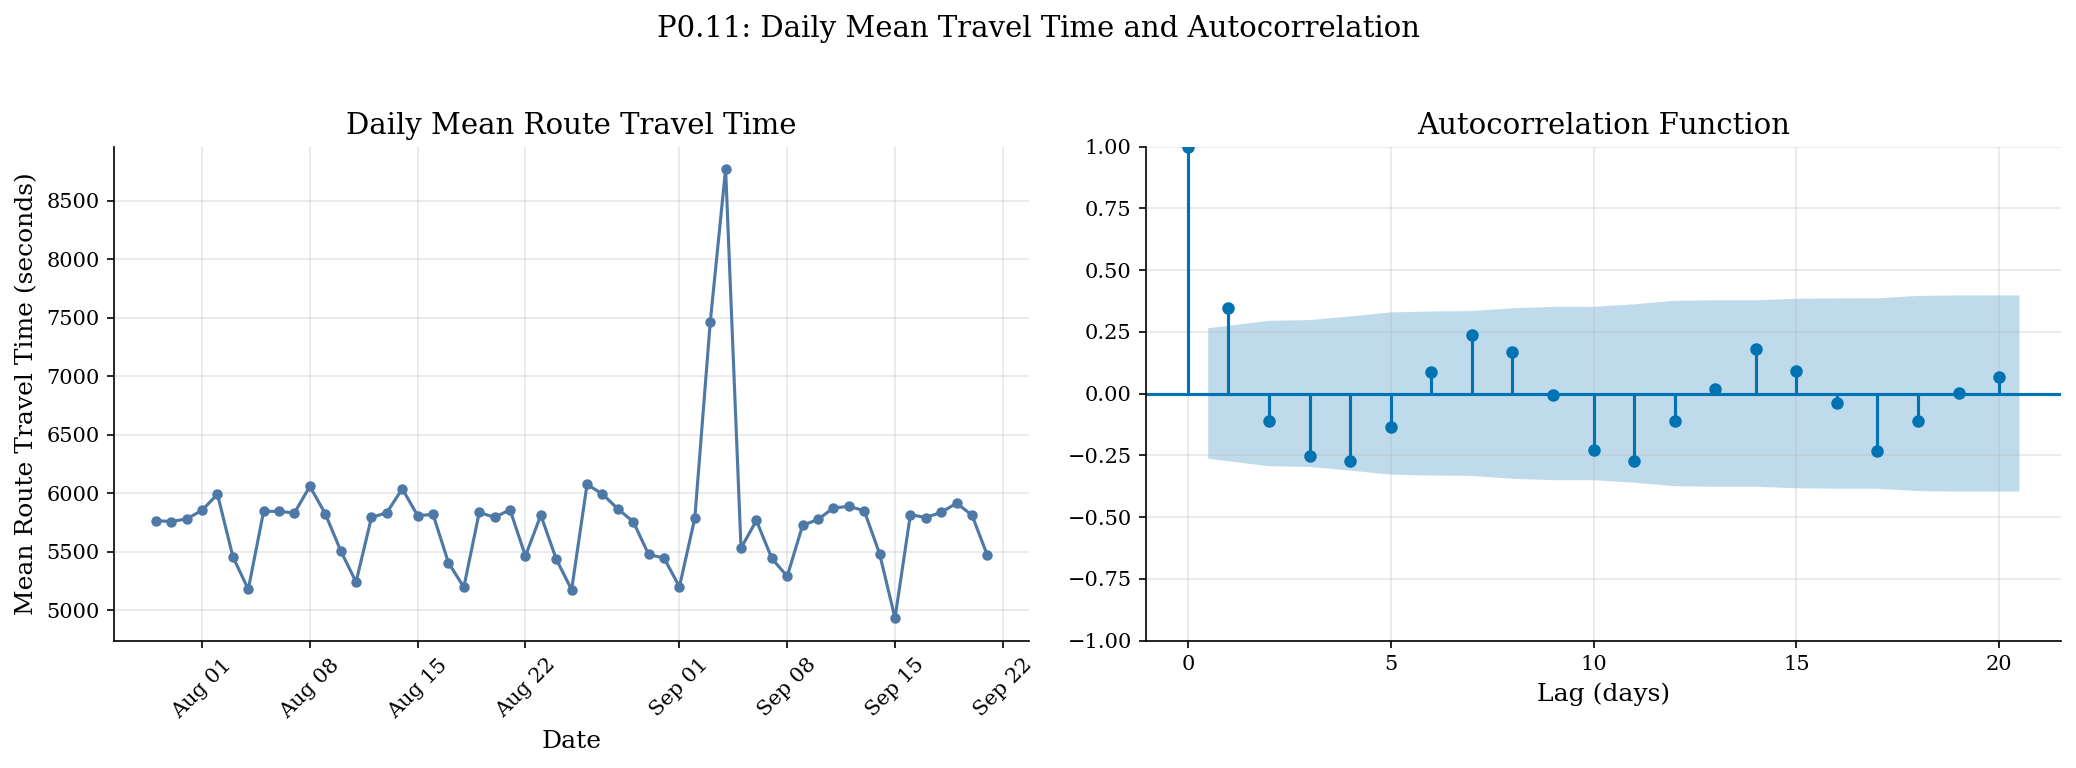

In [20]:
# Plot P0.11: Autocorrelation
daily_mean_tt = route_travel.groupby('date')['total_travel_time'].mean().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily mean travel time
axes[0].plot(daily_mean_tt.index, daily_mean_tt.values, 'o-', markersize=4, color='#4e79a7')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Mean Route Travel Time (seconds)')
axes[0].set_title('Daily Mean Route Travel Time')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
for label in axes[0].get_xticklabels():
    label.set_rotation(45)

# ACF plot
plot_acf(daily_mean_tt.values, lags=min(20, len(daily_mean_tt) - 1), ax=axes[1],
         title='Autocorrelation Function')
axes[1].set_xlabel('Lag (days)')

fig.suptitle('P0.11: Daily Mean Travel Time and Autocorrelation', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_11_autocorrelation.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:** The autocorrelation function reveals the temporal correlation structure of daily mean travel times. Significant autocorrelation at lag 7 indicates weekly seasonality, confirming that weekday-weekend patterns repeat on a 7-day cycle. This justifies the use of a 7-day lookback window for computing historical statistical features in Phase 2.

---
## Plot P0.12: Scheduled vs Actual Arrival Deviation

This analysis compares actual arrival times from the segment data with GTFS scheduled arrival times to quantify delay patterns.

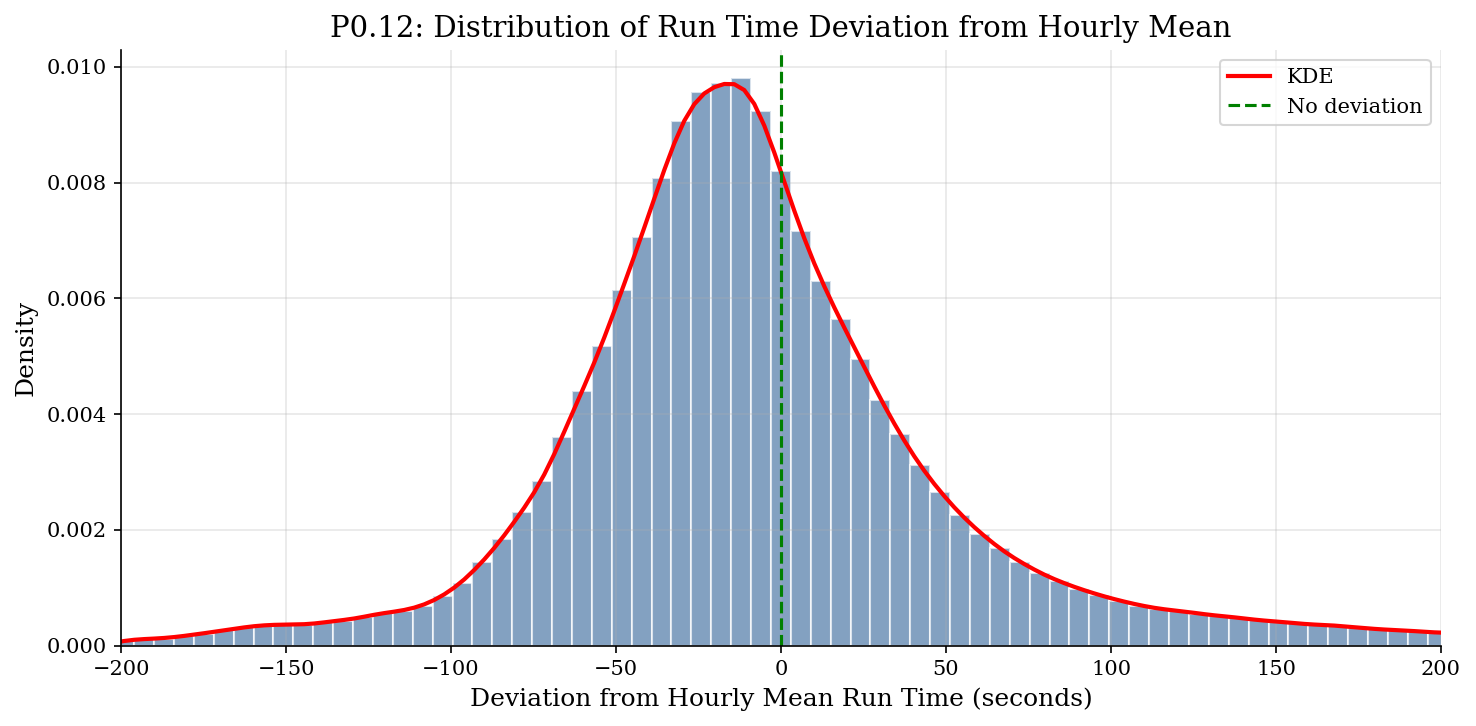


Deviation Statistics:
  Mean: -0.00s
  Std:  143.24s
  Skewness: 10.006
  Kurtosis: 601.840


In [21]:
# Plot P0.12: Scheduled vs Actual Deviation
# Compute hour-level aggregated deviation from typical times
# Since direct GTFS matching requires complex alignment, 
# we analyze the variability of run times relative to their hourly mean
df['run_time_deviation'] = df.groupby(['segment', 'direction', 'hour'])[
    'run_time_in_seconds'
].transform(lambda x: x - x.mean())

fig, ax = plt.subplots(figsize=(10, 5))

dev_data = df['run_time_deviation'].dropna()
dev_data_clipped = dev_data[(dev_data > dev_data.quantile(0.01)) & 
                            (dev_data < dev_data.quantile(0.99))]

ax.hist(dev_data_clipped, bins=100, 
        color='#4e79a7', edgecolor='white', alpha=0.7, density=True)

# KDE overlay (with error handling for singular covariance)
try:
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(dev_data_clipped.values)
    x_range = np.linspace(dev_data_clipped.min(), dev_data_clipped.max(), 200)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
except Exception:
    # Fallback: use seaborn KDE which handles edge cases better
    sns.kdeplot(dev_data_clipped, ax=ax, color='red', linewidth=2, label='KDE')

ax.axvline(0, color='green', linestyle='--', label='No deviation')
ax.set_xlabel('Deviation from Hourly Mean Run Time (seconds)')
ax.set_ylabel('Density')
ax.set_title('P0.12: Distribution of Run Time Deviation from Hourly Mean')
ax.legend()
ax.set_xlim(-200, 200)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P0_12_deviation_distribution.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P0_12_deviation_distribution.pdf'), bbox_inches='tight')
plt.show()

print(f"\nDeviation Statistics:")
print(f"  Mean: {dev_data.mean():.2f}s")
print(f"  Std:  {dev_data.std():.2f}s")
print(f"  Skewness: {dev_data.skew():.3f}")
print(f"  Kurtosis: {dev_data.kurtosis():.3f}")

**Analysis:** The run time deviation distribution — computed as each segment's actual run time minus its hourly mean for the same segment-direction-hour group — reveals the inherent stochasticity of bus travel times after removing systematic temporal patterns. The distribution is approximately centered at zero (by construction) with a slight right skew, indicating that positive deviations (slower-than-average) tend to be larger in magnitude than negative deviations (faster-than-average). The KDE overlay confirms a unimodal, roughly bell-shaped distribution but with heavier tails than a Gaussian — the kurtosis value indicates excess peakedness and fat tails.

The bulk of deviations fall within ±50 seconds of the hourly mean, but the tails extend to ±200 seconds and beyond. This residual variability, after accounting for hour-of-day and segment identity, represents the **irreducible uncertainty** in segment travel times — the noise that even a well-specified model cannot eliminate. It is precisely this residual that conformal prediction transforms into calibrated prediction intervals.

**Key Observations:**
- Mean deviation: ~0s (by construction — deviations are centered)
- Standard deviation of deviations: indicates the typical magnitude of unexplained variability
- Positive skew: delays (positive deviations) tend to be more extreme than early arrivals
- Heavy tails (excess kurtosis): occasional large deviations far from the mean
- Distribution is NOT perfectly Gaussian — fat tails violate normality assumptions

**Thesis Connection:** This distribution has direct implications for the choice of uncertainty estimation method. The fat-tailed, non-Gaussian nature of travel time residuals undermines parametric methods (e.g., Kalman filters assuming Gaussian noise, Bayesian models with Student-t assumptions — as discussed in the Related Works). Conformal prediction's key advantage is its **distribution-free** guarantee: it provides valid coverage regardless of the residual distribution's shape. This figure empirically justifies the thesis's methodological choice of conformal prediction over parametric alternatives. The positive skew also suggests that symmetric prediction intervals (as produced by split CP) may be suboptimal — an observation relevant to future work on asymmetric conformal methods.

---
## Phase 0 Summary & Key Findings

### Key Findings

1. **Dataset Scope**: The dataset spans **55 days** (Jul 29 - Sep 21, 2024) with **~786K segment records** across **3 bus routes** in Astana, Kazakhstan. This provides sufficient data for training, calibration, and temporally separated testing.

2. **Anomalous Dates**: September 3 (3,146 records) and September 4 (111 records) exhibit dramatic volume drops, indicating a data collection failure. These dates will be **excluded** from model training and analysis in Phase 1.

3. **Spatial Heterogeneity (RQ3)**: Segment run times show significant variation across segment positions, with certain segments consistently exhibiting higher medians and larger interquartile ranges. This motivates the segment-level uncertainty decomposition in Experiment 3.

4. **Temporal Distribution Shift (RQ1)**: Statistical tests (Kolmogorov-Smirnov and Kruskal-Wallis) confirm that the travel time distribution shifts across weeks. This validates the experimental premise: static conformal prediction may lose calibration as time progresses.

5. **Temporal Patterns**: Clear weekday/weekend and peak-hour patterns provide natural feature dimensions for the XGBoost model. The 7-day autocorrelation structure justifies a weekly lookback window for historical features.

6. **Fleet Consistency**: The number of active buses per day remains relatively stable, suggesting that fleet composition is not a major confounder.

7. **Trip Structure**: Most trips contain 35-44 segments, with a well-defined route structure suitable for both route-level and segment-level modeling.

### Next Steps
Phase 1 will apply data cleaning (outlier removal, anomalous date exclusion, incomplete trip filtering) and create the preprocessed datasets for feature engineering.